## Getting Stats for Overlaps of Bids from the Gene perspective


**Author**: Hope A. Townsend

### Summary of Methods
Here we overlap the final bidirectional regions with RefSeq gene annotations from NCBI (mm10_p6 and hg38_p14). Specifically we will get the fraction of transcripts that have bidirectionals within 1) Both exons and introns, 2) Neither exons or introns, 3) only exons, and 4) only introns.

We will also consider the fraction of transcriptions with a bidirectional in their 5' UTR, CDS, or 3' UTR.

In [1]:
library(data.table)
library(ggplot2)
library(cowplot)
library(stringr)


## 0. Get TSS Bidirectionals
**Note**: For the sake of consistency, we did not do additional filters before using the bid calls for this analysis. Similar results with filtered can be found in the supplemental and (https://github.com/Dowell-Lab/bidirectionals_merged/tree/main/notebooks).

### 0A. Get overlaps of bidirectionals with 1kb Gene TSS region (500bp upstream and downstream from TSS)
* **Note**: The Gene TSS file used in this case 

In [2]:
mumerge="/scratch/Shares/dowell/dbnascent/out/meta_analysis/mumerge/bidirectionals_dreg_tfit"
hg38_mumerge=fread(paste0(mumerge, "/hg38_tfit_dreg_bidirectionals.bed"))
mm10_mumerge=fread(paste0(mumerge, "/mm10_tfit_dreg_bidirectionals.bed"))
sort(unique(hg38_mumerge$V1))
sort(unique(mm10_mumerge$V1))

[1] "chr1"  "chr10" "chr11" "chr12" "chr13" "chr14" "chr15" "chr16" "chr17"
[10] "chr18" "chr19" "chr2"  "chr20" "chr21" "chr22" "chr3"  "chr4"  "chr5" 
[19] "chr6"  "chr7"  "chr8"  "chr9"  "chrX"  "chrY"

[1] "chr1"  "chr10" "chr11" "chr12" "chr13" "chr14" "chr15" "chr16" "chr17"
[10] "chr18" "chr19" "chr2"  "chr3"  "chr4"  "chr5"  "chr6"  "chr7"  "chr8" 
[19] "chr9"  "chrX"  "chrY"

In [12]:
# Create the 1kb TSS region
## HUMAN
hg38_trans <- fread("/scratch/Shares/dowell/genomes/hg38/ncbi/hg38_refseq_transcripts.bed")
hg38_trans[1:2,]
sort(unique(hg38_trans$V1))
# Get the TSS
hg38_trans$TSS <- hg38_trans$V2
trans[hg38_trans$V6 == "-",]$TSS <- hg38_trans[trans$V6 == "-",]$V3
prim_chroms = c("chr1", "chr10", "chr11", "chr12", "chr13", "chr14", "chr15", 
                "chr16", "chr17", "chr18", "chr19", "chr2", "chr20", "chr21", "chr22", 
                "chr3", "chr4", "chr5", "chr6", "chr7", "chr8", "chr9", 
                "chrX", "chrY")
length(prim_chroms)
nrow(hg38_trans)
hg38_trans = hg38_trans[hg38_trans$V1 %in% prim_chroms,]
nrow(hg38_trans)
hg38_trans[1:4,]
hg38_trans$start <- hg38_trans$TSS - 500
hg38_trans$stop <- hg38_trans$TSS + 500
write.table(hg38_trans[,c("V1", "start", "stop", "V4", "V5", "V6")], 
            "/scratch/Users/hoto7260/Bidir_Analysis/regions/hg38_refseq_prim_chrom_transcripts_1kbwinTSS.bed", 
            quote=FALSE, row.names=FALSE, col.names=FALSE, sep="\t")

V1,V2,V3,V4,V5,V6
<chr>,<int>,<int>,<chr>,<chr>,<chr>
chr1,11873,14409,DDX11L1:NR_046018.2,.,+
chr1,14361,29370,WASH7P:NR_024540.1,.,-


[1] "chr1"                    "chr1_GL383518v1_alt"    
  [3] "chr1_GL383519v1_alt"     "chr1_GL383520v2_alt"    
  [5] "chr1_KI270711v1_random"  "chr1_KI270713v1_random" 
  [7] "chr1_KI270761v1_alt"     "chr1_KI270762v1_alt"    
  [9] "chr1_KI270763v1_alt"     "chr1_KI270765v1_alt"    
 [11] "chr1_KI270766v1_alt"     "chr1_KI270892v1_alt"    
 [13] "chr1_KN196472v1_fix"     "chr1_KN196473v1_fix"    
 [15] "chr1_KN196474v1_fix"     "chr1_KN538360v1_fix"    
 [17] "chr1_KN538361v1_fix"     "chr1_KQ031383v1_fix"    
 [19] "chr1_KQ458383v1_alt"     "chr1_KQ458384v1_alt"    
 [21] "chr1_KQ983255v1_alt"     "chr1_KV880763v1_alt"    
 [23] "chr1_KZ208904v1_alt"     "chr1_KZ208906v1_fix"    
 [25] "chr1_MU273330v1_alt"     "chr1_MU273331v1_alt"    
 [27] "chr1_MU273332v1_alt"     "chr1_MU273333v1_fix"    
 [29] "chr1_MU273334v1_fix"     "chr1_MU273335v1_fix"    
 [31] "chr1_MU273336v1_fix"     "chr10"                  
 [33] "chr10_GL383545v1_alt"    "chr10_GL383546v1_alt"   
 [35] "chr10_KN196480v1_fix"    "chr10_KQ090020v1_alt"   
 [37] "chr10_KQ090021v1_fix"    "chr10_ML143354v1_fix"   
 [39] "chr10_ML143355v1_fix"    "chr10_MU273367v1_fix"   
 [41] "chr11"                   "chr11_JH159136v1_alt"   
 [43] "chr11_JH159137v1_alt"    "chr11_KI270827v1_alt"   
 [45] "chr11_KI270829v1_alt"    "chr11_KI270830v1_alt"   
 [47] "chr11_KI270831v1_alt"    "chr11_KI270832v1_alt"   
 [49] "chr11_KI270902v1_alt"    "chr11_KI270903v1_alt"   
 [51] "chr11_KI270927v1_alt"    "chr11_KN196481v1_fix"   
 [53] "chr11_KN538368v1_alt"    "chr11_KQ090022v1_fix"   
 [55] "chr11_KQ759759v2_fix"    "chr11_KV766195v1_fix"   
 [57] "chr11_KZ559108v1_fix"    "chr11_KZ559109v1_fix"   
 [59] "chr11_KZ559110v1_alt"    "chr11_KZ559111v1_alt"   
 [61] "chr11_ML143357v1_fix"    "chr11_ML143358v1_fix"   
 [63] "chr11_ML143359v1_fix"    "chr11_ML143360v1_fix"   
 [65] "chr11_MU273368v1_alt"    "chr11_MU273369v1_fix"   
 [67] "chr11_MU273370v1_fix"    "chr11_MU273371v1_fix"   
 [69] "chr12"                   "chr12_GL383550v2_alt"   
 [71] "chr12_GL383551v1_alt"    "chr12_GL383553v2_alt"   
 [73] "chr12_GL877875v1_alt"    "chr12_GL877876v1_alt"   
 [75] "chr12_KI270833v1_alt"    "chr12_KI270834v1_alt"   
 [77] "chr12_KI270835v1_alt"    "chr12_KI270837v1_alt"   
 [79] "chr12_KI270904v1_alt"    "chr12_KN538369v1_fix"   
 [81] "chr12_KN538370v1_fix"    "chr12_KQ090023v1_alt"   
 [83] "chr12_KZ208916v1_fix"    "chr12_KZ208917v1_fix"   
 [85] "chr12_KZ559112v1_alt"    "chr12_ML143361v1_fix"   
 [87] "chr12_ML143362v1_fix"    "chr12_MU273372v1_fix"   
 [89] "chr13"                   "chr13_KI270838v1_alt"   
 [91] "chr13_KI270839v1_alt"    "chr13_KI270840v1_alt"   
 [93] "chr13_KI270842v1_alt"    "chr13_KN538371v1_fix"   
 [95] "chr13_KN538372v1_fix"    "chr13_KN538373v1_fix"   
 [97] "chr13_KQ090025v1_alt"    "chr13_ML143365v1_fix"   
 [99] "chr14"                   "chr14_GL000194v1_random"
[101] "chr14_KI270844v1_alt"    "chr14_KI270845v1_alt"   
[103] "chr14_KI270846v1_alt"    "chr14_KI270847v1_alt"   
[105] "chr14_KZ208919v1_alt"    "chr14_KZ208920v1_fix"   
[107] "chr14_ML143367v1_fix"    "chr14_ML143368v1_alt"   
[109] "chr14_MU273373v1_fix"    "chr15"                  
[111] "chr15_GL383554v1_alt"    "chr15_GL383555v2_alt"   
[113] "chr15_KI270727v1_random" "chr15_KI270848v1_alt"   
[115] "chr15_KI270849v1_alt"    "chr15_KI270850v1_alt"   
[117] "chr15_KI270851v1_alt"    "chr15_KI270852v1_alt"   
[119] "chr15_KI270905v1_alt"    "chr15_KI270906v1_alt"   
[121] "chr15_KN538374v1_fix"    "chr15_KQ031389v1_alt"   
[123] "chr15_ML143369v1_fix"    "chr15_ML143370v1_fix"   
[125] "chr15_ML143371v1_fix"    "chr15_ML143372v1_fix"   
[127] "chr15_MU273374v1_fix"    "chr15_MU273375v1_alt"   
[129] "chr16"                   "chr16_GL383556v1_alt"   
[131] "chr16_GL383557v1_alt"    "chr16_KI270728v1_random"
[133] "chr16_KI270853v1_alt"    "chr16_KI270854v1_alt"   
[135] "chr16_KI270855v1_alt"    "chr16_KI270856v1_alt"   
[137] "chr16_KQ090026v1_alt"    "chr16_KQ090027v1_alt"   


ERROR: Error: Object 'trans' not found amongst [V1, V2, V3, V4, V5, V6, TSS]


In [13]:
# Create the 1kb TSS region
## MOUSE
mm10_trans <- fread("/scratch/Shares/dowell/genomes/mm10/ncbi/mm10_refseq_transcripts.bed")
mm10_trans[1:2,]
sort(unique(mm10_trans$V1))
# Get the TSS
mm10_trans$TSS <- mm10_trans$V2
mm10_trans[mm10_trans$V6 == "-",]$TSS <- mm10_trans[mm10_trans$V6 == "-",]$V3
prim_chroms = c("chr1", "chr10", "chr11", "chr12", "chr13", "chr14", "chr15", 
                "chr16", "chr17", "chr18", "chr19", "chr2", "chr20", "chr21", "chr22", 
                "chr3", "chr4", "chr5", "chr6", "chr7", "chr8", "chr9", 
                "chrX", "chrY")
length(prim_chroms)
nrow(mm10_trans)
mm10_trans = mm10_trans[mm10_trans$V1 %in% prim_chroms,]
nrow(mm10_trans)
mm10_trans[1:4,]
mm10_trans$start <- mm10_trans$TSS - 500
mm10_trans$stop <- mm10_trans$TSS + 500
write.table(mm10_trans[,c("V1", "start", "stop", "V4", "V5", "V6")], 
            "/scratch/Users/hoto7260/Bidir_Analysis/regions/mm10_refseq_prim_chrom_transcripts_600bpTSS.bed", 
            quote=FALSE, row.names=FALSE, col.names=FALSE, sep="\t")

V1,V2,V3,V4,V5,V6
<chr>,<int>,<int>,<chr>,<chr>,<chr>
chr1,3214481,3671498,Xkr4:NM_001011874.1,.,-
chr1,4119865,4360303,Rp1:NM_001370921.1,.,-


[1] "chr1"                 "chr1_GL456211_random" "chr1_GL456212_random"
 [4] "chr1_GL456221_random" "chr1_KK082441_alt"    "chr10"               
 [7] "chr10_KQ030491_fix"   "chr11"                "chr11_KB469739_fix"  
[10] "chr12"                "chr12_KB469740_fix"   "chr13"               
[13] "chr14"                "chr15"                "chr16"               
[16] "chr17"                "chr17_KB469742_fix"   "chr18"               
[19] "chr19"                "chr19_JH792830_fix"   "chr19_KQ030494_fix"  
[22] "chr2"                 "chr3"                 "chr3_KQ030484_fix"   
[25] "chr4"                 "chr4_GL456216_random" "chr4_GL456350_random"
[28] "chr4_JH584292_random" "chr4_JH584293_random" "chr4_JH584294_random"
[31] "chr4_JH584295_random" "chr4_JH792826_fix"    "chr4_KQ030485_fix"   
[34] "chr4_KQ030486_fix"    "chr4_KQ030487_fix"    "chr4_KQ030488_fix"   
[37] "chr4_KQ030489_fix"    "chr5"                 "chr5_JH584299_random"
[40] "chr5_JH792827_fix"    "chr6"                 "chr6_KK082442_fix"   
[43] "chr6_KK082443_fix"    "chr7"                 "chr7_GL456219_random"
[46] "chr7_JH792828_fix"    "chr8"                 "chr9"                
[49] "chr9_KB469738v3_fix"  "chr9_KQ030490_fix"    "chrUn_JH584304"      
[52] "chrX"                 "chrX_GL456233_random" "chrX_KQ030495_fix"   
[55] "chrX_KQ030496_fix"    "chrX_KQ030497_fix"    "chrY"                
[58] "chrY_JH584300_random" "chrY_JH792832_fix"    "chrY_JH792833_fix"   
[61] "chrY_JH792834_fix"

[1] 24

[1] 46057

[1] 45756

V1,V2,V3,V4,V5,V6,TSS
<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>
chr1,3214481,3671498,Xkr4:NM_001011874.1,.,-,3671498
chr1,4119865,4360303,Rp1:NM_001370921.1,.,-,4360303
chr1,4290845,4409241,Rp1:NM_001195662.1,.,-,4409241
chr1,4343506,4360314,Rp1:NM_011283.2,.,-,4360314


In [ ]:
#!/bin/bash
#HUMAN
TSS_BED=/scratch/Users/hoto7260/Bidir_Analysis/regions/hg38_refseq_prim_chrom_transcripts_1kbwinTSS.bed
BID=/scratch/Shares/dowell/dbnascent/out/meta_analysis/mumerge/bidirectionals_dreg_tfit/hg38_tfit_dreg_bidirectionals.bed
out=/scratch/Users/hoto7260/Bidir_Analysis/overlaps/overlaps_hg38_TSS1kb_bids.bed
# echo "Getting intersections unfiltered Bids with Transcript TSSs"
bedtools intersect -a $TSS_BED -b $BID -wo > $out
#MOUSE
TSS_BED=/scratch/Users/hoto7260/Bidir_Analysis/regions/mm10_refseq_prim_chrom_transcripts_1kbwinTSS.bed
BID=/scratch/Shares/dowell/dbnascent/out/meta_analysis/mumerge/bidirectionals_dreg_tfit/mm10_tfit_dreg_bidirectionals.bed
out=/scratch/Users/hoto7260/Bidir_Analysis/overlaps/overlaps_mm10_TSS1kb_bids.bed
# echo "Getting intersections unfiltered Bids with Transcript TSSs"
bedtools intersect -a $TSS_BED -b $BID -wo > $out


#### For transcripts with multiple TSS bids, get the one whose mu is closest to Gene TSS

#### HUMAN

In [3]:
overlaps <- fread("/scratch/Users/hoto7260/Bidir_Analysis/overlaps/overlaps_hg38_TSS1kb_bids.bed")
dim(overlaps)
overlaps[1:2,]

[1] 105046     13

V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13
<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<chr>,<int>
chr1,11373,12373,DDX11L1:NR_046018.2,.,+,chr1,12182,12456,"tfit,dreg",1,.,191
chr1,16936,17936,MIR6859-1:NR_106918.1,.,-,chr1,16631,16963,dreg,12,.,27


0%  25%  50%  75% 100% 
   0   56  215  475 1682

[1] 105046

[1] 104898

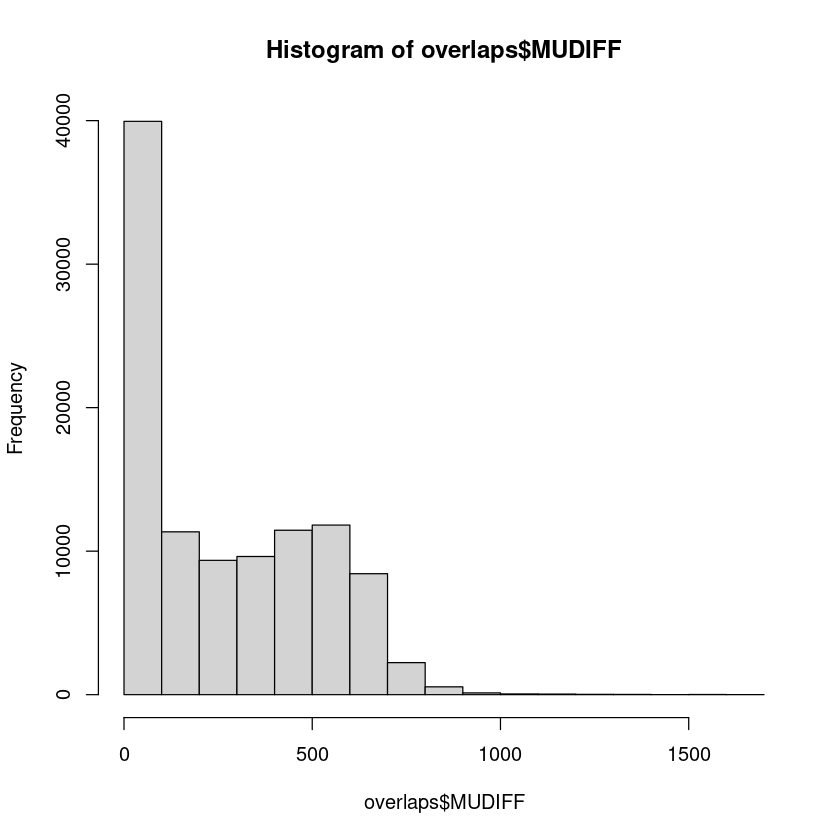

In [4]:
overlaps$Length <- overlaps$V9 - overlaps$V8
overlaps$mu <- as.integer((overlaps$V9 + overlaps$V8)/2)
overlaps$TSS <- as.integer((overlaps$V2 + overlaps$V3)/2)
overlaps$MUDIFF = abs(overlaps$mu - overlaps$TSS)
hist(overlaps$MUDIFF)
quantile(overlaps$MUDIFF)

# REMOVE any with distance > 1000
nrow(overlaps)
overlaps <- overlaps[overlaps$MUDIFF < 1000,]
nrow(overlaps)

In [5]:
# WITH Top Mu clsoest
length(unique(overlaps$V4))
# for each transcript with MORE THAN ONE coordinating promoter bidirectional, get one most overlapping
dup_transcripts <- overlaps$V4[duplicated(overlaps$V4)]
length(dup_transcripts)
# make unique id
overlaps$unique_id = paste0(overlaps$V4, "_", overlaps$mu)
# Get ones with top mu 
keep_list_filtmu <- c()
for (transcript in dup_transcripts) {
    # get all overlaps
    filtered <- overlaps[overlaps$V4 == transcript,]
    # order by fraction of TSS region overlapping
    filtered <- filtered[order(filtered$MUDIFF),]
    # add unique id of first
    keep_list_filtmu <- c(keep_list_filtmu, filtered$unique_id[1])
    }

[1] 69506

[1] 35392

[1] 38041

[1] 31465

[1] 69506    18

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


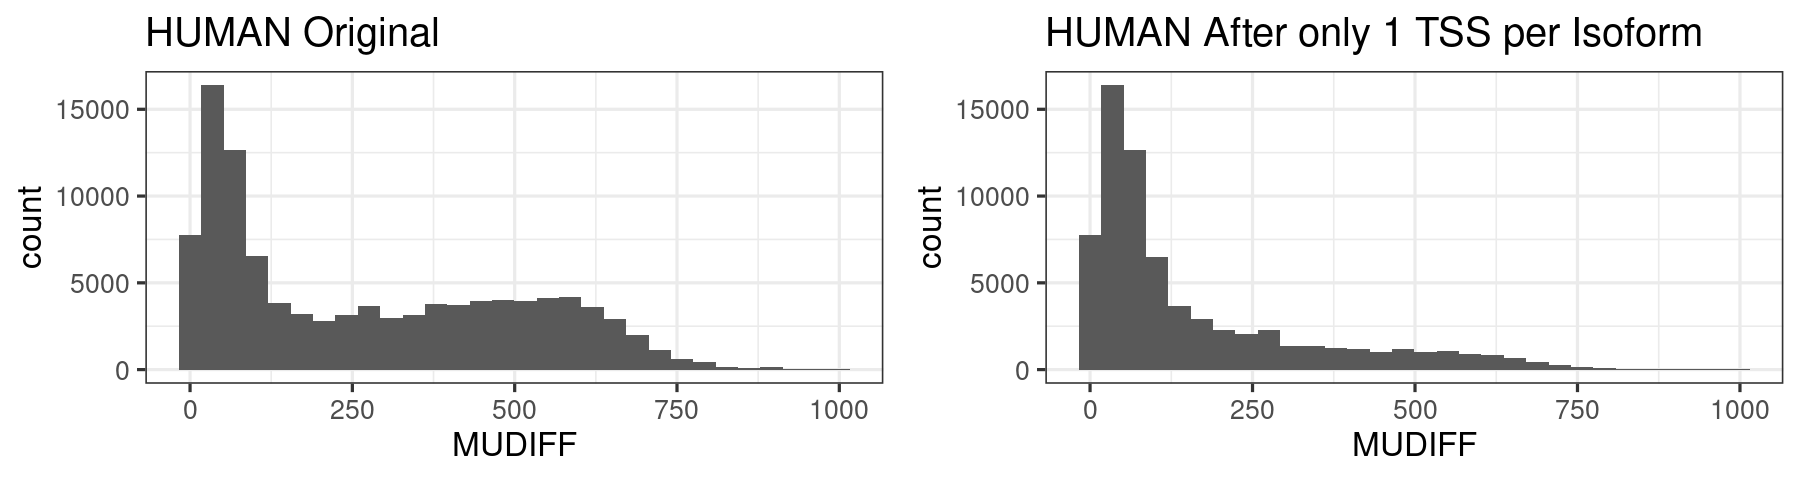

In [6]:
# Get final version
non_dup = overlaps[!overlaps$V4 %in% dup_transcripts,]
nrow(non_dup)
dup = overlaps[overlaps$unique_id %in% keep_list_filtmu,]
nrow(dup)
hg38_tss_filt <- rbind(dup, non_dup)
dim(hg38_tss_filt)

p1 <- ggplot(overlaps, aes(x=MUDIFF)) + geom_histogram() + theme_bw(base_size=20) + 
ggtitle("HUMAN Original")
p2 <- ggplot(hg38_tss_filt, aes(x=MUDIFF)) + geom_histogram() + theme_bw(base_size=20) + 
ggtitle("HUMAN After only 1 TSS per Isoform")
options(repr.plot.height=4, repr.plot.width=15)
plot_grid(p1, p2, nrow=1)

#### MOUSE

[1] 54785    13

V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13
<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<chr>,<int>
chr1,3670998,3671998,Xkr4:NM_001011874.1,.,-,chr1,3670923,3671237,tfit,23,.,239
chr1,3670998,3671998,Xkr4:NM_001011874.1,.,-,chr1,3671408,3672036,"tfit,dreg",23,.,590


0%  25%  50%  75% 100% 
   0   45  185  459 1436

[1] 54785

[1] 54681

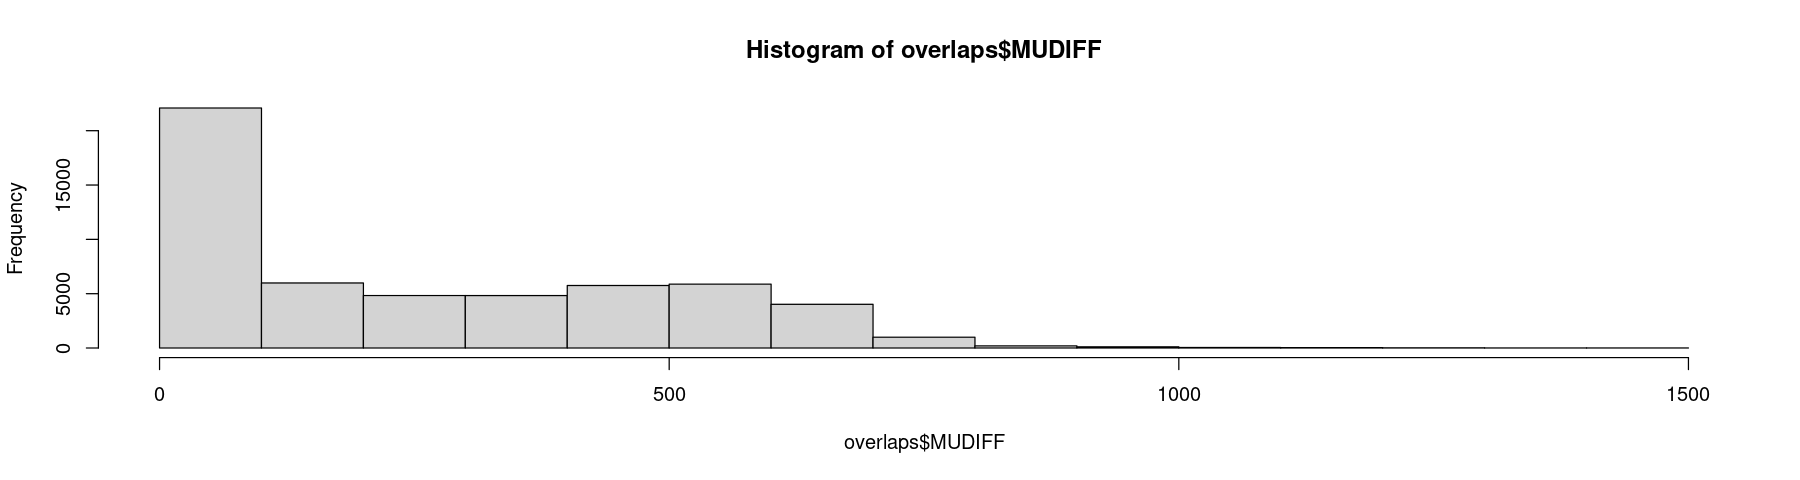

In [7]:
overlaps <- fread("/scratch/Users/hoto7260/Bidir_Analysis/overlaps/overlaps_mm10_TSS1kb_bids.bed")
dim(overlaps)
overlaps[1:2,]
overlaps$Length <- overlaps$V9 - overlaps$V8
overlaps$mu <- as.integer((overlaps$V9 + overlaps$V8)/2)
overlaps$TSS <- as.integer((overlaps$V2 + overlaps$V3)/2)
overlaps$MUDIFF = abs(overlaps$mu - overlaps$TSS)
hist(overlaps$MUDIFF)
quantile(overlaps$MUDIFF)

# REMOVE any with distance > 1000
nrow(overlaps)
overlaps <- overlaps[overlaps$MUDIFF < 1000,]
nrow(overlaps)

In [8]:
# WITH Top Mu clsoest
length(unique(overlaps$V4))
# for each transcript with MORE THAN ONE coordinating promoter bidirectional, get one most overlapping
dup_transcripts <- overlaps$V4[duplicated(overlaps$V4)]
length(dup_transcripts)
# make unique id
overlaps$unique_id = paste0(overlaps$V4, "_", overlaps$mu)
# Get ones with top mu 
keep_list_filtmu <- c()
for (transcript in dup_transcripts) {
    # get all overlaps
    filtered <- overlaps[overlaps$V4 == transcript,]
    # order by fraction of TSS region overlapping
    filtered <- filtered[order(filtered$MUDIFF),]
    # add unique id of first
    keep_list_filtmu <- c(keep_list_filtmu, filtered$unique_id[1])
    }

[1] 36061

[1] 18620

[1] 19744

[1] 16317

[1] 36061    18

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


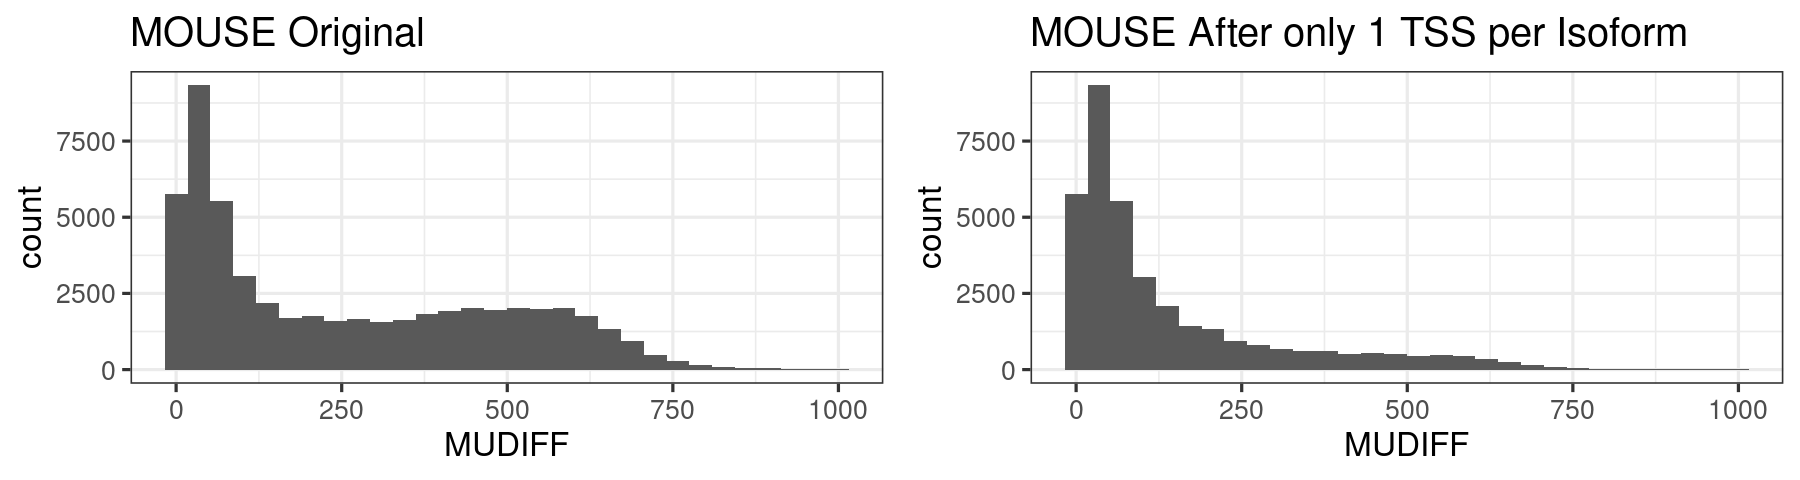

In [9]:
# Get final version
non_dup = overlaps[!overlaps$V4 %in% dup_transcripts,]
nrow(non_dup)
dup = overlaps[overlaps$unique_id %in% keep_list_filtmu,]
nrow(dup)
mm10_tss_filt <- rbind(dup, non_dup)
dim(mm10_tss_filt)

p1 <- ggplot(overlaps, aes(x=MUDIFF)) + geom_histogram() + theme_bw(base_size=20) + 
ggtitle("MOUSE Original")
p2 <- ggplot(mm10_tss_filt, aes(x=MUDIFF)) + geom_histogram() + theme_bw(base_size=20) + 
ggtitle("MOUSE After only 1 TSS per Isoform")
options(repr.plot.height=4, repr.plot.width=15)
plot_grid(p1, p2, nrow=1)

## 2. Read in overlaps of Bidirectionals with Genome Features


In [ ]:
!#/bin/bash
# HUMAN
GDIR=/scratch/Shares/dowell/genomes/hg38/ncbi
BID=/scratch/Shares/dowell/dbnascent/out/meta_analysis/mumerge/bidirectionals_dreg_tfit/hg38_tfit_dreg_bidirectionals.bed
INTRON=${GDIR}/hg38_refseq_introns.bed
EXON=${GDIR}/hg38_refseq_exons.bed

OUT=/scratch/Users/hoto7260/Bidir_Analysis/overlaps/over_hg38_bid_introns_50perc.bed
bedtools intersect -a ${BID} -b ${INTRON} -wo -f 0.5 > ${OUT}
OUT=/scratch/Users/hoto7260/Bidir_Analysis/overlaps/over_hg38_bid_exons_50perc.bed
bedtools intersect -a ${BID} -b ${EXON} -wo -f 0.5 > ${OUT}

# MOUSE
GDIR=/scratch/Shares/dowell/genomes/mm10/ncbi
BID=/scratch/Shares/dowell/dbnascent/out/meta_analysis/mumerge/bidirectionals_dreg_tfit/mm10_tfit_dreg_bidirectionals.bed
INTRON=${GDIR}/mm10_refseq_introns.bed
EXON=${GDIR}/mm10_refseq_exons.bed

OUT=/scratch/Users/hoto7260/Bidir_Analysis/overlaps/over_mm10_bid_introns_50perc.bed
bedtools intersect -a ${BID} -b ${INTRON} -wo -f 0.5 > ${OUT}
OUT=/scratch/Users/hoto7260/Bidir_Analysis/overlaps/over_mm10_bid_exons_50perc.bed
bedtools intersect -a ${BID} -b ${EXON} -wo -f 0.5 > ${OUT}

In [10]:
hg38_over_introns <- fread("/scratch/Users/hoto7260/Bidir_Analysis/overlaps/over_hg38_bid_introns_50perc.bed")
hg38_over_exons <- fread("/scratch/Users/hoto7260/Bidir_Analysis/overlaps/over_hg38_bid_exons_50perc.bed")
mm10_over_introns <- fread("/scratch/Users/hoto7260/Bidir_Analysis/overlaps/over_mm10_bid_introns_50perc.bed")
mm10_over_exons <- fread("/scratch/Users/hoto7260/Bidir_Analysis/overlaps/over_mm10_bid_exons_50perc.bed")

hg38_over_introns$Gene <- str_split_fixed(hg38_over_introns$V10, ":", 2)[,1]
hg38_over_exons$Gene <- str_split_fixed(hg38_over_exons$V10, ":", 2)[,1]
mm10_over_introns$Gene <- str_split_fixed(mm10_over_introns$V10, ":", 2)[,1]
mm10_over_exons$Gene <- str_split_fixed(mm10_over_exons$V10, ":", 2)[,1]

hg38_over_introns[1:2,]
hg38_over_exons[1:2,]
mm10_over_introns[1:2,]
mm10_over_exons[1:2,]

V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,Gene
<chr>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<chr>
chr1,12182,12456,"tfit,dreg",1,.,chr1,12227,12612,DDX11L1:NR_046018.2,.,+,229,DDX11L1
chr1,15084,15360,dreg,9,.,chr1,15038,15795,WASH7P:NR_024540.1,.,-,276,WASH7P


V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,Gene
<chr>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<chr>
chr1,13264,13506,tfit,14,.,chr1,13220,14409,DDX11L1:NR_046018.2,.,+,242,DDX11L1
chr1,14655,14811,"tfit,dreg",14,.,chr1,14361,14829,WASH7P:NR_024540.1,.,-,156,WASH7P


V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,Gene
<chr>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<chr>
chr1,3230180,3230580,dreg,1,.,chr1,3216968,3421701,Xkr4:NM_001011874.1,.,-,400,Xkr4
chr1,3230650,3230880,dreg,1,.,chr1,3216968,3421701,Xkr4:NM_001011874.1,.,-,230,Xkr4


V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,Gene
<chr>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<chr>
chr1,3670923,3671237,tfit,23,.,chr1,3670551,3671498,Xkr4:NM_001011874.1,.,-,314,Xkr4
chr1,4491470,4491746,dreg,12,.,chr1,4490927,4492668,Sox17:NM_011441.5,.,-,276,Sox17


### 2A. Get the fractions & numbers of Transcripts & Genes with:
With and without including TSS Bids:
* Bid calls in introns
* Bid calls in exons
* Bid calls in introns and exons
* Bid calls in neither introns or exons

In [14]:
# Get total numbers of genes for both
hg38_trans$Gene <- str_split_fixed(hg38_trans$V4, ":", 2)[,1]
hg38_tot_isoforms = length(unique(hg38_trans$V4))
hg38_tot_genes= length(unique(hg38_trans$Gene))
cat("HG38 Total Isoforms:", hg38_tot_isoforms, "\tTotal Genes:", hg38_tot_genes)
mm10_trans$Gene <- str_split_fixed(mm10_trans$V4, ":", 2)[,1]
mm10_tot_isoforms = length(unique(mm10_trans$V4))
mm10_tot_genes= length(unique(mm10_trans$Gene))
cat("\nMM10 Total Isoforms:", mm10_tot_isoforms, "\tTotal Genes:", mm10_tot_genes)

HG38 Total Isoforms: 98221 	Total Genes: 33514
MM10 Total Isoforms: 45756 	Total Genes: 26182

#### With TSS Bids

In [15]:
# Get the fractions & numbers of Transcripts & Genes with:
# Bid calls in introns
hg38_isof_introns = unique(hg38_over_introns$V10)
hg38_gene_introns = unique(hg38_over_introns$Gene)
mm10_isof_introns = unique(mm10_over_introns$V10)
mm10_gene_introns = unique(mm10_over_introns$Gene)
# Bid calls in exons
hg38_isof_exons = unique(hg38_over_exons$V10)
hg38_gene_exons = unique(hg38_over_exons$Gene)
mm10_isof_exons = unique(mm10_over_exons$V10)
mm10_gene_exons = unique(mm10_over_exons$Gene)
# Bid calls in introns and exons
hg38_isof_both = intersect(hg38_isof_introns, hg38_isof_exons)
hg38_gene_both = intersect(hg38_gene_introns, hg38_gene_exons)
mm10_isof_both = intersect(mm10_isof_introns, mm10_isof_exons)
mm10_gene_both = intersect(mm10_gene_introns, mm10_gene_exons)
# Bid calls in neither introns or exons
hg38_isof_none = setdiff(hg38_trans$V4, union(hg38_isof_introns, hg38_isof_exons))
hg38_gene_none = setdiff(hg38_trans$Gene, union(hg38_gene_introns, hg38_gene_exons))
mm10_isof_none = setdiff(mm10_trans$V4, union(mm10_isof_introns, mm10_isof_exons))
mm10_gene_none = setdiff(mm10_trans$Gene, union(mm10_gene_introns, mm10_gene_exons))
# Bid calls in only introns
hg38_isof_introns_only = setdiff(hg38_isof_introns, hg38_isof_exons)
hg38_gene_introns_only = setdiff(hg38_gene_introns, hg38_gene_exons)
mm10_isof_introns_only = setdiff(mm10_isof_introns, mm10_isof_exons)
mm10_gene_introns_only = setdiff(mm10_gene_introns, mm10_gene_exons)
# Bid calls in only Exons
hg38_isof_exons_only = setdiff(hg38_isof_exons, hg38_isof_introns )
hg38_gene_exons_only = setdiff(hg38_gene_exons, hg38_gene_introns )
mm10_isof_exons_only = setdiff(mm10_isof_exons, mm10_isof_introns)
mm10_gene_exons_only = setdiff(mm10_gene_exons, mm10_gene_introns)

In [16]:
# table with fraction and number
ie_table <- as.data.frame(data.table("Genome"=c(rep("hg38",8 ), rep("mm10", 8)),
                       "Gene_Metric"=rep(c("Isoform", "Gene"), 8),
                      "Category"=rep(c("Only\nIntrons", "Only\nIntrons",
                                         "Only\nExons", "Only\nExons",
                                         "Both", "Both", 
                                         "Neither", "Neither"),2), 
                       "Number"=c(length(hg38_isof_introns_only), length(hg38_gene_introns_only), 
                                 length(hg38_isof_exons_only), length(hg38_gene_exons_only), 
                                 length(hg38_isof_both), length(hg38_gene_both), 
                                 length(hg38_isof_none), length(hg38_gene_none), 
                                 length(mm10_isof_introns_only), length(mm10_gene_introns_only), 
                                 length(mm10_isof_exons_only), length(mm10_gene_exons_only), 
                                 length(mm10_isof_both), length(mm10_gene_both), 
                                 length(mm10_isof_none), length(mm10_gene_none)), 
                       "Total"=c(rep(c(hg38_tot_isoforms, hg38_tot_genes), 4), 
                                rep(c(mm10_tot_isoforms, mm10_tot_genes), 4))))
ie_table$Per_Transcripts <- ie_table$Number/ie_table$Total*100
ie_table

Genome,Gene_Metric,Category,Number,Total,Per_Transcripts
<chr>,<chr>,<chr>,<int>,<int>,<dbl>
hg38,Isoform,Only Introns,22159,98221,22.560349
hg38,Gene,Only Introns,6606,33514,19.711165
hg38,Isoform,Only Exons,2915,98221,2.967797
hg38,Gene,Only Exons,1846,33514,5.508146
hg38,Isoform,Both,54106,98221,55.085980
hg38,Gene,Both,14289,33514,42.635913
hg38,Isoform,Neither,19041,98221,19.385875
hg38,Gene,Neither,10773,33514,32.144775
mm10,Isoform,Only Introns,11264,45756,24.617536


In [17]:
x_order = c("Only\nExons", "Only\nIntrons", "Both", "Neither")

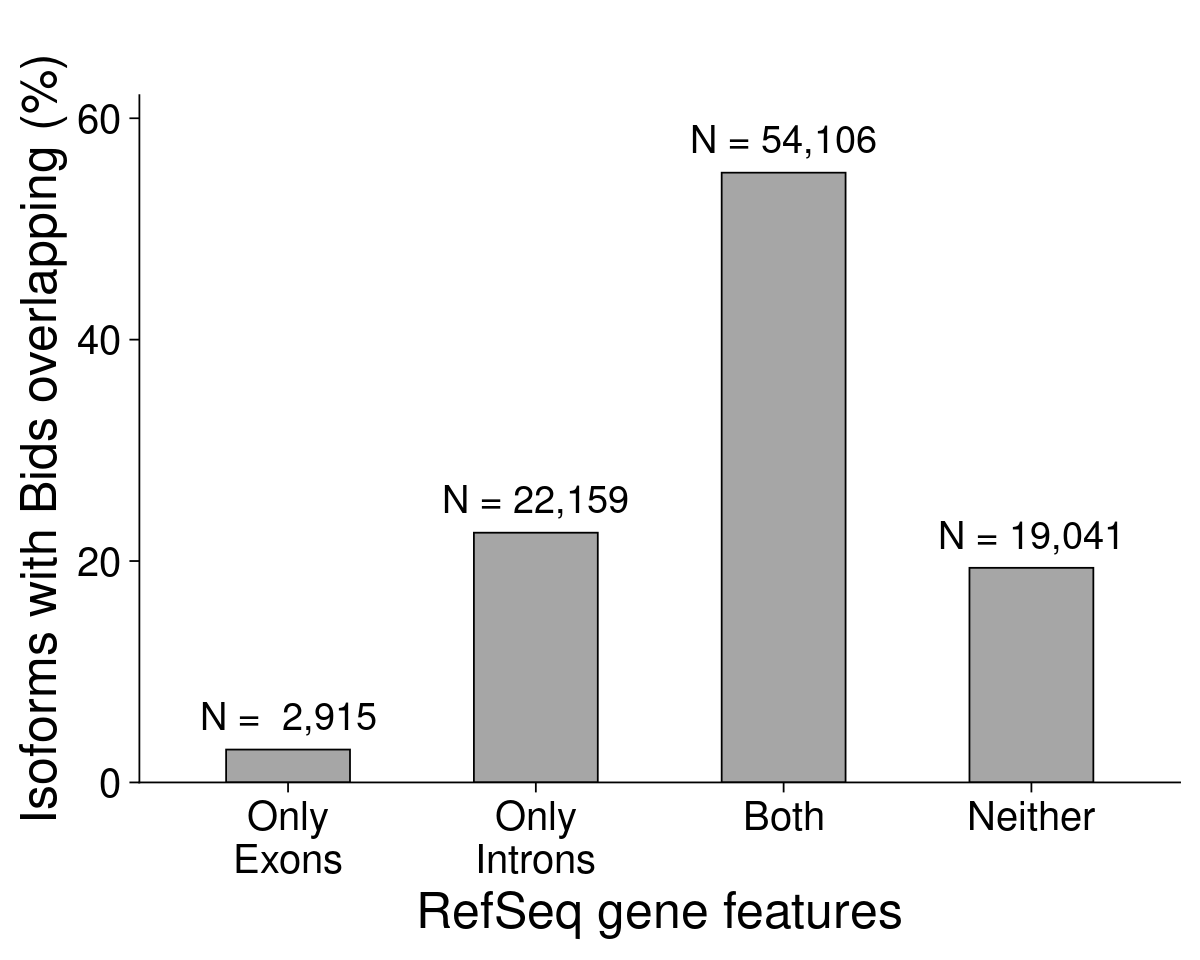

In [18]:

options(repr.plot.width=10, repr.plot.height=8)
data_use = ie_table[ie_table$Genome=="hg38" & ie_table$Gene_Metric=="Isoform",]
# Get the numbers to plot
rownames(data_use) <- data_use$Category
percs_plot = data_use[x_order,]$Per_Transcripts + 3
nums_plot = data_use[x_order,]$Number 
isof_bid_overlap_hg38_noheader <- ggplot2::ggplot(data_use,
       aes(x=factor(Category, 
                    levels=x_order), y=as.numeric(Per_Transcripts))) +
geom_bar(stat="identity", width=0.5, color='black',fill="gray65")+
  scale_y_continuous(expand = c(0, 0)) +
labs(title=" ",
     x="RefSeq gene features", 
     y = "Isoforms with Bids overlapping (%)") + #"% of bidirectionals overlapping")+
annotate("text", x=c(1,2,3,4),
         y=percs_plot, 
         label= paste("N =", format(nums_plot, 
       scientific = FALSE, big.mark = ',')), size = 8) + 
theme_cowplot(24) +
coord_cartesian(ylim=c(0, max(percs_plot)+4)) +
theme(plot.title = element_text(hjust = 0.5),
      title = element_text(size = 30), 
      axis.title = element_text(size = 30), 
      axis.text = element_text(size = 24),
     axis.text.x = element_text(size = 24),
     legend.position="none") 

isof_bid_overlap_hg38_noheader

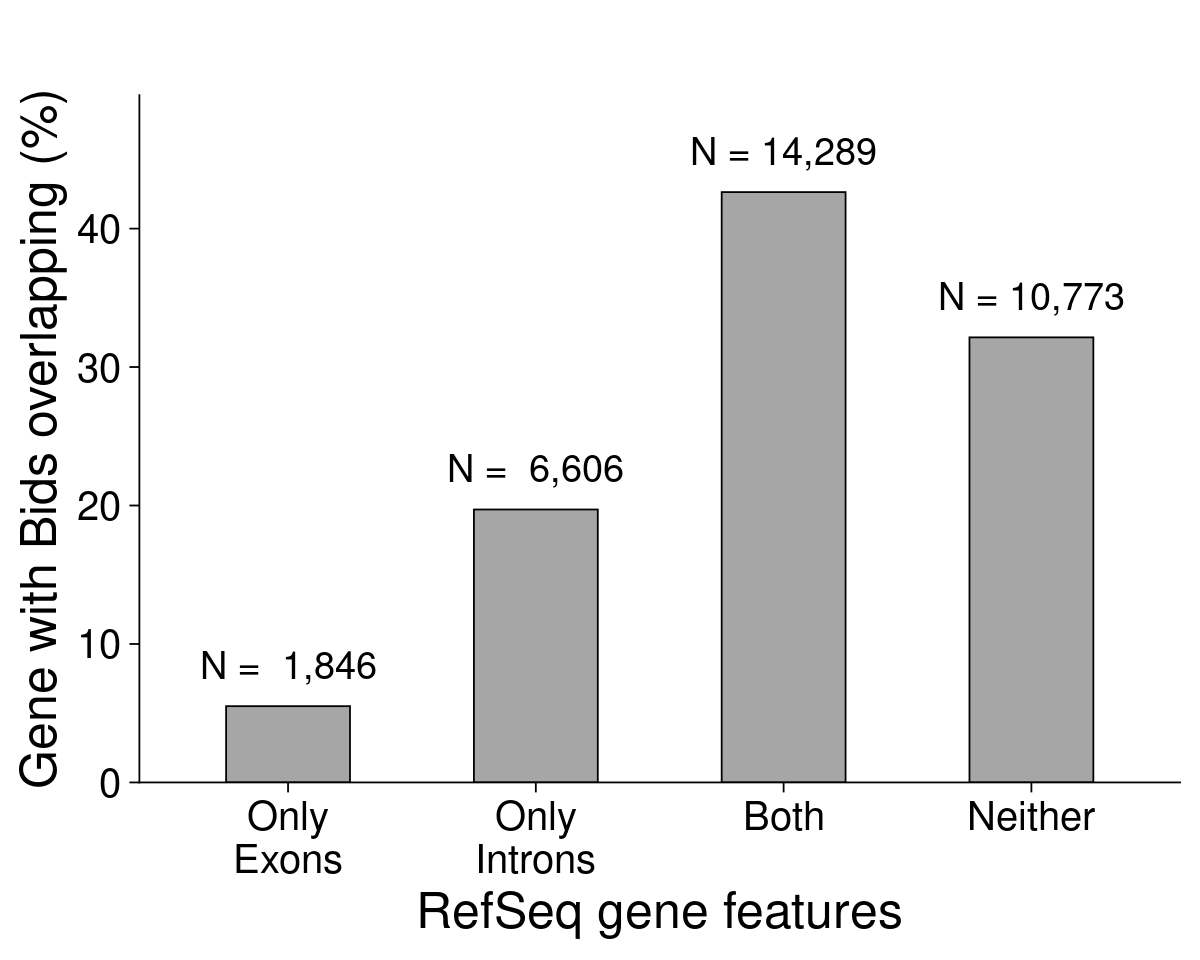

In [19]:

options(repr.plot.width=10, repr.plot.height=8)
data_use = ie_table[ie_table$Genome=="hg38" & ie_table$Gene_Metric=="Gene",]
# Get the numbers to plot
rownames(data_use) <- data_use$Category
percs_plot = data_use[x_order,]$Per_Transcripts + 3
nums_plot = data_use[x_order,]$Number 

gene_bid_overlap_hg38_noheader <- ggplot2::ggplot(data_use,
       aes(x=factor(Category, 
                    levels=x_order), y=as.numeric(Per_Transcripts))) +
geom_bar(stat="identity", width=0.5, color='black',fill="gray65")+
  scale_y_continuous(expand = c(0, 0)) +
labs(title=" ",
     x="RefSeq gene features", 
     y = "Gene with Bids overlapping (%)") + #"% of bidirectionals overlapping")+
annotate("text", x=c(1,2,3,4),
         y=percs_plot, 
         label= paste("N =", format(nums_plot, 
       scientific = FALSE, big.mark = ',')), size = 8) + 
theme_cowplot(24) +
coord_cartesian(ylim=c(0, max(percs_plot)+4)) +
theme(plot.title = element_text(hjust = 0.5),
      title = element_text(size = 30), 
      axis.title = element_text(size = 30), 
      axis.text = element_text(size = 24),
     axis.text.x = element_text(size = 24),
     legend.position="none") 

gene_bid_overlap_hg38_noheader

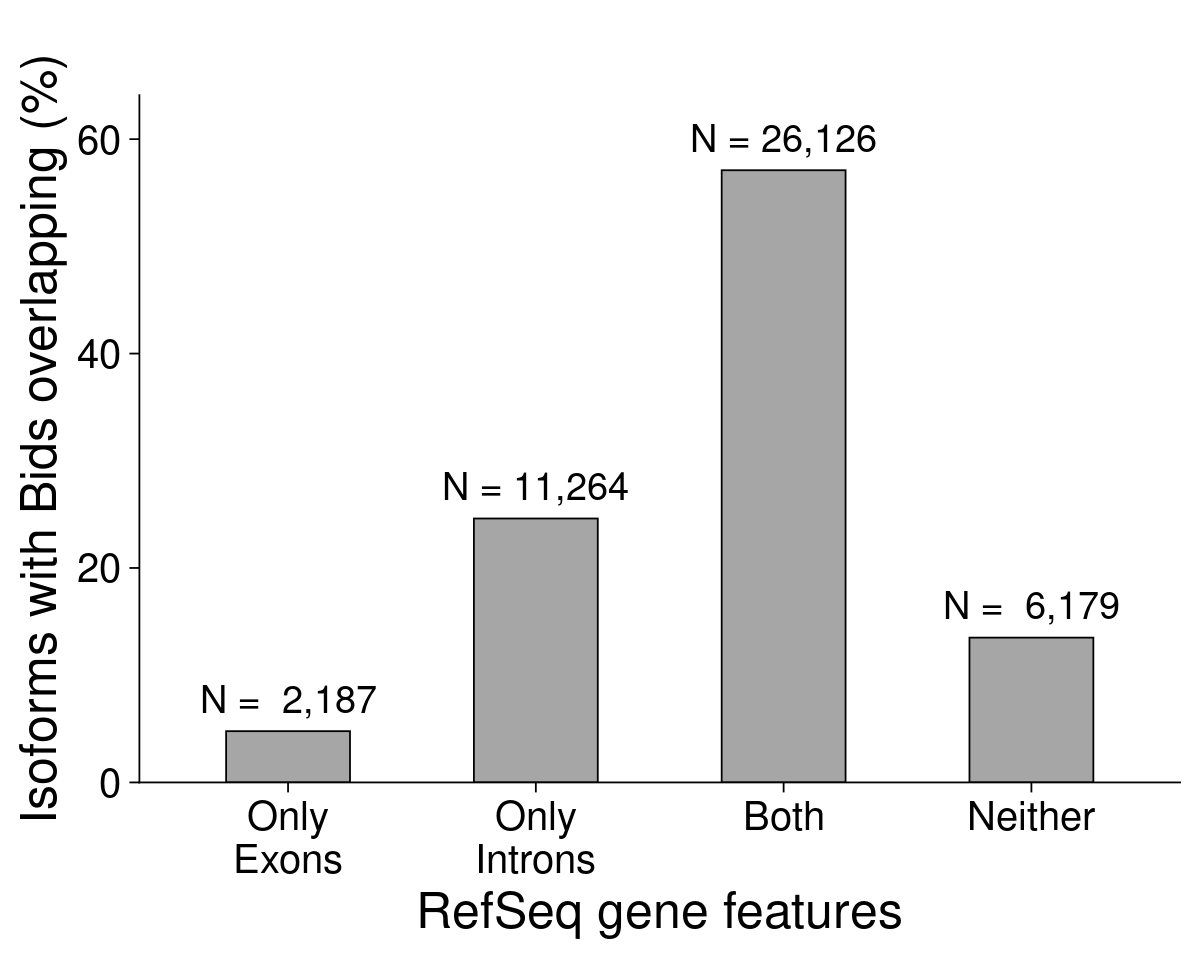

In [20]:

options(repr.plot.width=10, repr.plot.height=8)
data_use = ie_table[ie_table$Genome=="mm10" & ie_table$Gene_Metric=="Isoform",]
# Get the numbers to plot
rownames(data_use) <- data_use$Category
percs_plot = data_use[x_order,]$Per_Transcripts + 3
nums_plot = data_use[x_order,]$Number 
isof_bid_overlap_mm10_noheader <- ggplot2::ggplot(data_use,
       aes(x=factor(Category, 
                    levels=x_order), y=as.numeric(Per_Transcripts))) +
geom_bar(stat="identity", width=0.5, color='black',fill="gray65")+
  scale_y_continuous(expand = c(0, 0)) +
labs(title=" ",
     x="RefSeq gene features", 
     y = "Isoforms with Bids overlapping (%)") + #"% of bidirectionals overlapping")+
annotate("text", x=c(1,2,3,4),
         y=percs_plot, 
         label= paste("N =", format(nums_plot, 
       scientific = FALSE, big.mark = ',')), size = 8) + 
theme_cowplot(24) +
coord_cartesian(ylim=c(0, max(percs_plot)+4)) +
theme(plot.title = element_text(hjust = 0.5),
      title = element_text(size = 30), 
      axis.title = element_text(size = 30), 
      axis.text = element_text(size = 24),
     axis.text.x = element_text(size = 24),
     legend.position="none") 

isof_bid_overlap_mm10_noheader

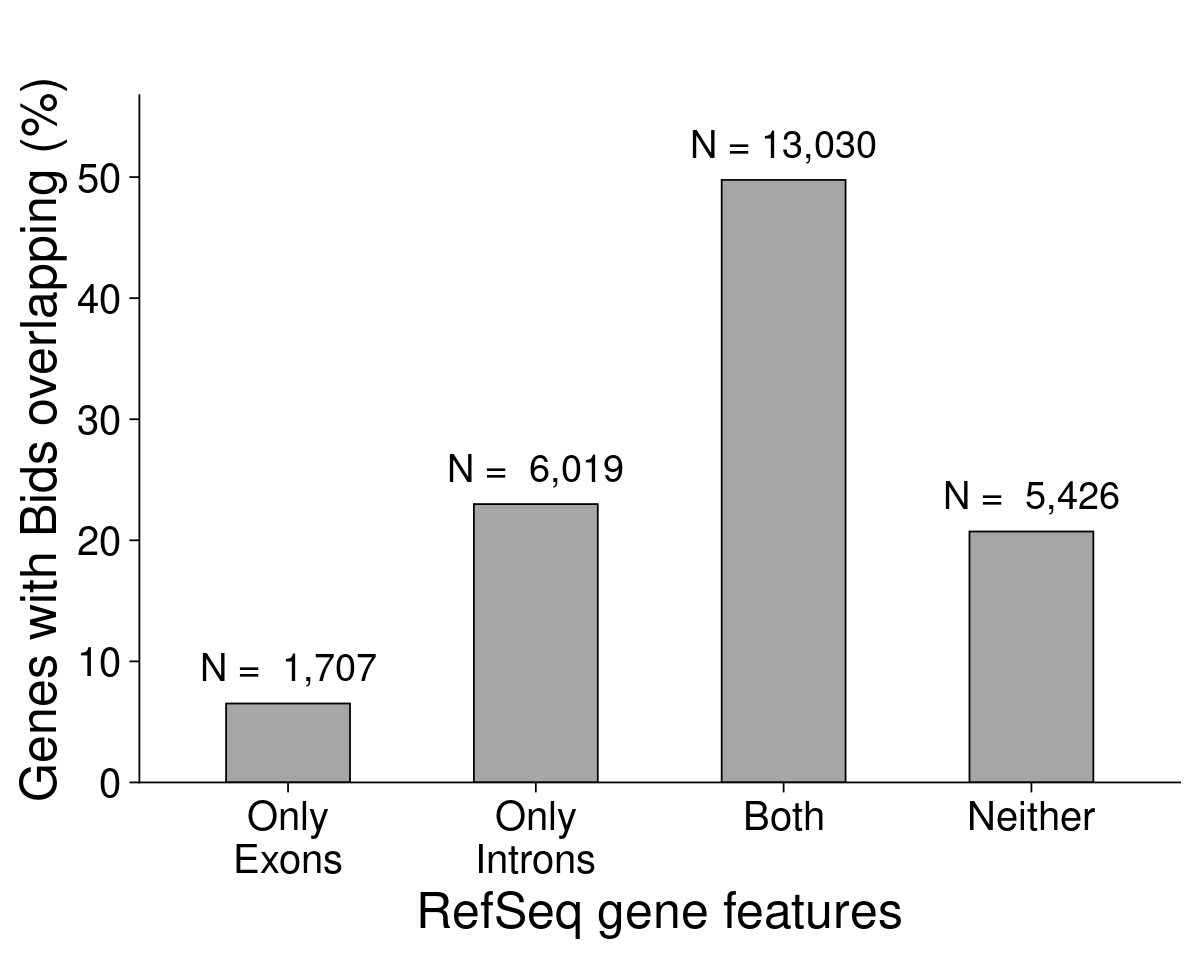

In [21]:

options(repr.plot.width=10, repr.plot.height=8)
data_use = ie_table[ie_table$Genome=="mm10" & ie_table$Gene_Metric=="Gene",]
# Get the numbers to plot
rownames(data_use) <- data_use$Category
percs_plot = data_use[x_order,]$Per_Transcripts + 3
nums_plot = data_use[x_order,]$Number
gene_bid_overlap_mm10_noheader <- ggplot2::ggplot(data_use,
       aes(x=factor(Category, 
                    levels=x_order), y=as.numeric(Per_Transcripts))) +
geom_bar(stat="identity", width=0.5, color='black',fill="gray65")+
  scale_y_continuous(expand = c(0, 0)) +
labs(title=" ",
     x="RefSeq gene features", 
     y = "Genes with Bids overlapping (%)") + #"% of bidirectionals overlapping")+
annotate("text", x=c(1,2,3,4),
         y=percs_plot, 
         label= paste("N =", format(nums_plot, 
       scientific = FALSE, big.mark = ',')), size = 8) + 
theme_cowplot(24) +
coord_cartesian(ylim=c(0, max(percs_plot)+4)) +
theme(plot.title = element_text(hjust = 0.5),
      title = element_text(size = 30), 
      axis.title = element_text(size = 30), 
      axis.text = element_text(size = 24),
     axis.text.x = element_text(size = 24),
     legend.position="none") 

gene_bid_overlap_mm10_noheader

In [22]:
ggsave(isof_bid_overlap_hg38_noheader, width = 10, height = 8,
       filename = "/Users/hoto7260/projects/For_others/paper_figures/hg38_geneISOF_refseq_overlap_bids.pdf", 
       bg = "transparent")
ggsave(gene_bid_overlap_hg38_noheader, width = 10, height = 8,
       filename = "/Users/hoto7260/projects/For_others/paper_figures/hg38_gene_refseq_overlap_bids.pdf", 
       bg = "transparent")
ggsave(isof_bid_overlap_mm10_noheader, width = 10, height = 8,
       filename = "/Users/hoto7260/projects/For_others/paper_figures/mm10_geneISOF_refseq_overlap_bids.pdf", 
       bg = "transparent")
ggsave(gene_bid_overlap_mm10_noheader, width = 10, height = 8,
       filename = "/Users/hoto7260/projects/For_others/paper_figures/mm10_gene_refseq_overlap_bids.pdf", 
       bg = "transparent")

#### Without TSS Bids

In [23]:
hg38_tss_filt[1:2,]
hg38_tss_filt$name <- paste0(hg38_tss_filt$V1, ":", hg38_tss_filt$mu)
mm10_tss_filt$name <- paste0(mm10_tss_filt$V1, ":", mm10_tss_filt$mu)

V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,Length,mu,TSS,MUDIFF,unique_id
<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>
chr1,16936,17936,MIR6859-1:NR_106918.1,.,-,chr1,17453,17621,tfit,128,.,168,168,17537,17436,101,MIR6859-1:NR_106918.1_17537
chr1,181887,182887,DDX11L17:NR_148357.1,.,+,chr1,181984,182180,"tfit,dreg",1,.,196,196,182082,182387,305,DDX11L17:NR_148357.1_182082


In [24]:
# Filter so TSS Bids no longer count
hg38_over_introns[1:2,]
hg38_over_introns$mu <- as.integer((hg38_over_introns$V2 + hg38_over_introns$V3)/2)
hg38_over_exons$mu <- as.integer((hg38_over_exons$V2 + hg38_over_exons$V3)/2)
mm10_over_introns$mu <- as.integer((mm10_over_introns$V2 + mm10_over_introns$V3)/2)
mm10_over_exons$mu <- as.integer((mm10_over_exons$V2 + mm10_over_exons$V3)/2)
hg38_over_introns$name <- paste0(hg38_over_introns$V1, ":", hg38_over_introns$mu)
hg38_over_exons$name <- paste0(hg38_over_exons$V1, ":", hg38_over_exons$mu)
mm10_over_introns$name <- paste0(mm10_over_introns$V1, ":", mm10_over_introns$mu)
mm10_over_exons$name <- paste0(mm10_over_exons$V1, ":", mm10_over_exons$mu)

hg38_over_introns <- hg38_over_introns[!hg38_over_introns$name %in% hg38_tss_filt$name,]
hg38_over_exons <- hg38_over_exons[!hg38_over_exons$name %in% hg38_tss_filt$name,]
mm10_over_introns <- mm10_over_introns[!mm10_over_introns$name %in% mm10_tss_filt$name,]
mm10_over_exons <- mm10_over_exons[!mm10_over_exons$name %in% mm10_tss_filt$name,]


V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,Gene
<chr>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<chr>
chr1,12182,12456,"tfit,dreg",1,.,chr1,12227,12612,DDX11L1:NR_046018.2,.,+,229,DDX11L1
chr1,15084,15360,dreg,9,.,chr1,15038,15795,WASH7P:NR_024540.1,.,-,276,WASH7P


In [25]:
# Get the fractions & numbers of Transcripts & Genes with:
# Bid calls in introns
hg38_isof_introns = unique(hg38_over_introns$V10)
hg38_gene_introns = unique(hg38_over_introns$Gene)
mm10_isof_introns = unique(mm10_over_introns$V10)
mm10_gene_introns = unique(mm10_over_introns$Gene)
# Bid calls in exons
hg38_isof_exons = unique(hg38_over_exons$V10)
hg38_gene_exons = unique(hg38_over_exons$Gene)
mm10_isof_exons = unique(mm10_over_exons$V10)
mm10_gene_exons = unique(mm10_over_exons$Gene)
# Bid calls in introns and exons
hg38_isof_both = intersect(hg38_isof_introns, hg38_isof_exons)
hg38_gene_both = intersect(hg38_gene_introns, hg38_gene_exons)
mm10_isof_both = intersect(mm10_isof_introns, mm10_isof_exons)
mm10_gene_both = intersect(mm10_gene_introns, mm10_gene_exons)
# Bid calls in neither introns or exons
hg38_isof_none = setdiff(hg38_trans$V4, union(hg38_isof_introns, hg38_isof_exons))
hg38_gene_none = setdiff(hg38_trans$Gene, union(hg38_gene_introns, hg38_gene_exons))
mm10_isof_none = setdiff(mm10_trans$V4, union(mm10_isof_introns, mm10_isof_exons))
mm10_gene_none = setdiff(mm10_trans$Gene, union(mm10_gene_introns, mm10_gene_exons))
# Bid calls in only introns
hg38_isof_introns_only = setdiff(hg38_isof_introns, hg38_isof_exons)
hg38_gene_introns_only = setdiff(hg38_gene_introns, hg38_gene_exons)
mm10_isof_introns_only = setdiff(mm10_isof_introns, mm10_isof_exons)
mm10_gene_introns_only = setdiff(mm10_gene_introns, mm10_gene_exons)
# Bid calls in only Exons
hg38_isof_exons_only = setdiff(hg38_isof_exons, hg38_isof_introns )
hg38_gene_exons_only = setdiff(hg38_gene_exons, hg38_gene_introns )
mm10_isof_exons_only = setdiff(mm10_isof_exons, mm10_isof_introns)
mm10_gene_exons_only = setdiff(mm10_gene_exons, mm10_gene_introns)

In [26]:
# table with fraction and number
ie_table <- as.data.frame(data.table("Genome"=c(rep("hg38",8 ), rep("mm10", 8)),
                       "Gene_Metric"=rep(c("Isoform", "Gene"), 8),
                      "Category"=rep(c("Only\nIntrons", "Only\nIntrons",
                                         "Only\nExons", "Only\nExons",
                                         "Both", "Both", 
                                         "Neither", "Neither"),2), 
                       "Number"=c(length(hg38_isof_introns_only), length(hg38_gene_introns_only), 
                                 length(hg38_isof_exons_only), length(hg38_gene_exons_only), 
                                 length(hg38_isof_both), length(hg38_gene_both), 
                                 length(hg38_isof_none), length(hg38_gene_none), 
                                 length(mm10_isof_introns_only), length(mm10_gene_introns_only), 
                                 length(mm10_isof_exons_only), length(mm10_gene_exons_only), 
                                 length(mm10_isof_both), length(mm10_gene_both), 
                                 length(mm10_isof_none), length(mm10_gene_none)), 
                       "Total"=c(rep(c(hg38_tot_isoforms, hg38_tot_genes), 4), 
                                rep(c(mm10_tot_isoforms, mm10_tot_genes), 4))))
ie_table$Per_Transcripts <- ie_table$Number/ie_table$Total*100
ie_table

Genome,Gene_Metric,Category,Number,Total,Per_Transcripts
<chr>,<chr>,<chr>,<int>,<int>,<dbl>
hg38,Isoform,Only Introns,24209,98221,24.647479
hg38,Gene,Only Introns,7321,33514,21.844602
hg38,Isoform,Only Exons,2674,98221,2.722432
hg38,Gene,Only Exons,1578,33514,4.708480
hg38,Isoform,Both,51260,98221,52.188432
hg38,Gene,Both,13259,33514,39.562571
hg38,Isoform,Neither,20078,98221,20.441657
hg38,Gene,Neither,11356,33514,33.884347
mm10,Isoform,Only Introns,12959,45756,28.321969


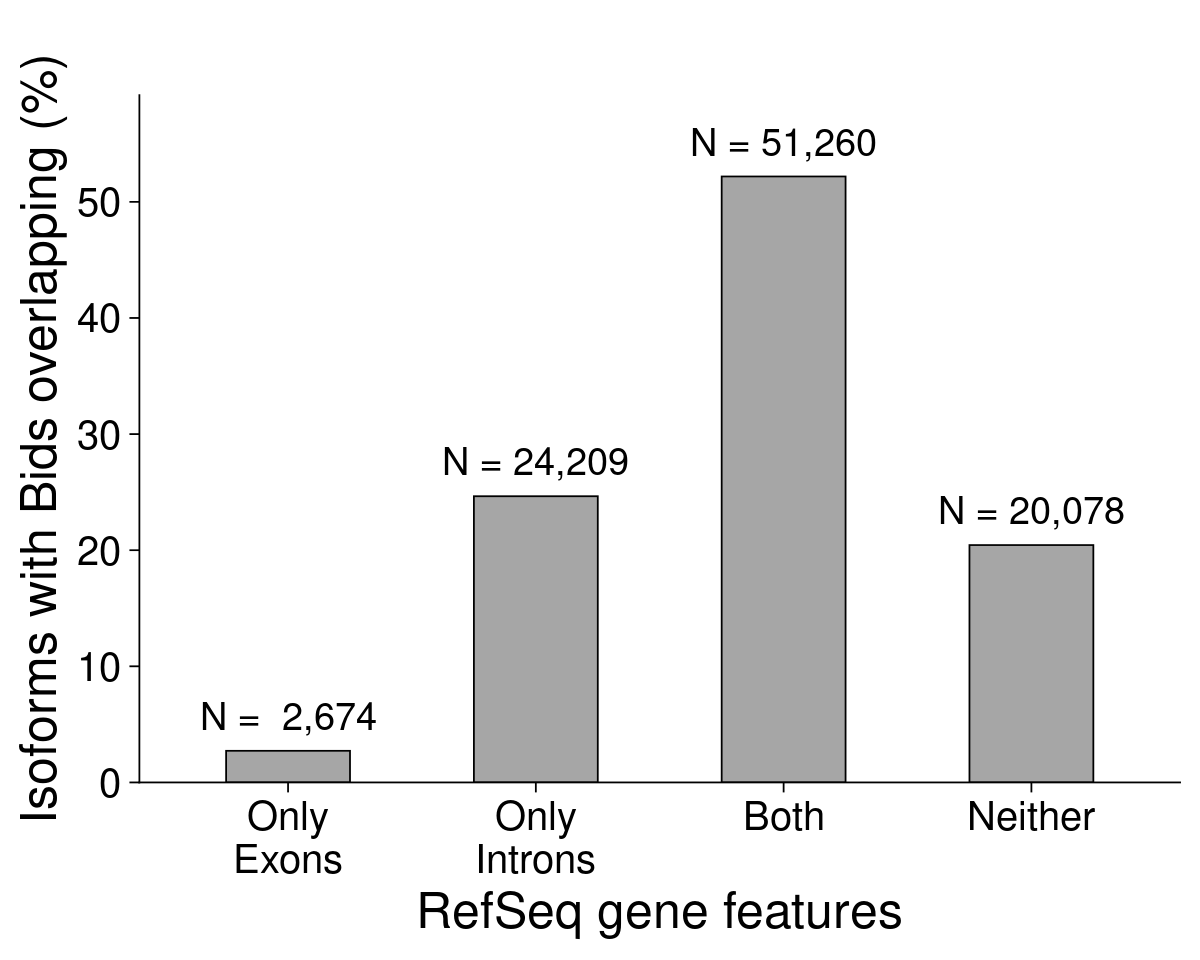

In [27]:

options(repr.plot.width=10, repr.plot.height=8)
data_use = ie_table[ie_table$Genome=="hg38" & ie_table$Gene_Metric=="Isoform",]
# Get the numbers to plot
rownames(data_use) <- data_use$Category
percs_plot = data_use[x_order,]$Per_Transcripts + 3
nums_plot = data_use[x_order,]$Number 

notss_isof_bid_overlap_hg38_noheader <- ggplot2::ggplot(data_use,
       aes(x=factor(Category, 
                    levels=x_order), y=as.numeric(Per_Transcripts))) +
geom_bar(stat="identity", width=0.5, color='black',fill="gray65")+
  scale_y_continuous(expand = c(0, 0)) +
labs(title=" ",
     x="RefSeq gene features", 
     y = "Isoforms with Bids overlapping (%)") + #"% of bidirectionals overlapping")+
annotate("text", x=c(1,2,3,4),
         y=percs_plot, 
         label= paste("N =", format(nums_plot, 
       scientific = FALSE, big.mark = ',')), size = 8) + 
theme_cowplot(24) +
coord_cartesian(ylim=c(0, max(percs_plot)+4)) +
theme(plot.title = element_text(hjust = 0.5),
      title = element_text(size = 30), 
      axis.title = element_text(size = 30), 
      axis.text = element_text(size = 24),
     axis.text.x = element_text(size = 24),
     legend.position="none") 

notss_isof_bid_overlap_hg38_noheader

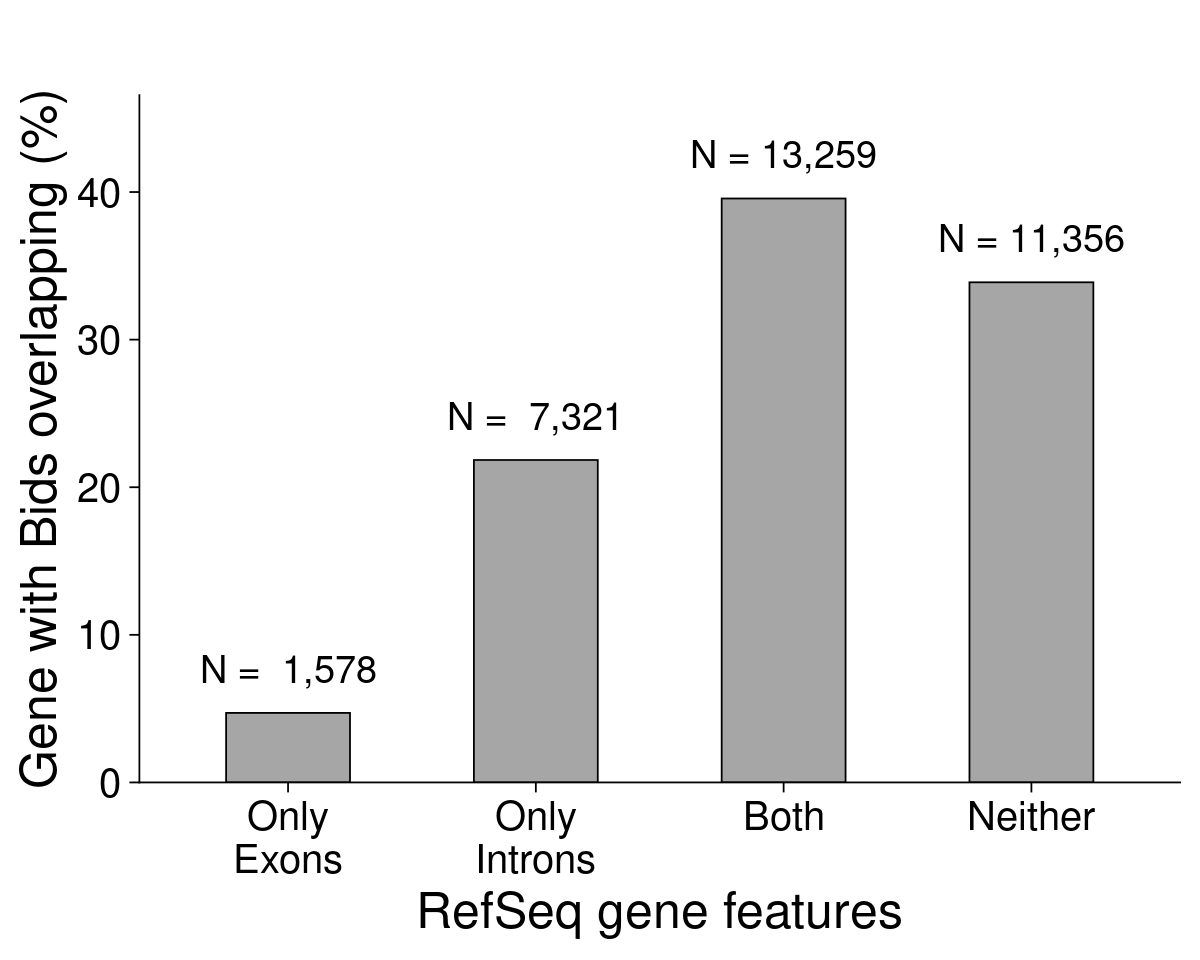

In [28]:

options(repr.plot.width=10, repr.plot.height=8)
data_use = ie_table[ie_table$Genome=="hg38" & ie_table$Gene_Metric=="Gene",]
# Get the numbers to plot
rownames(data_use) <- data_use$Category
percs_plot = data_use[x_order,]$Per_Transcripts + 3
nums_plot = data_use[x_order,]$Number 

notss_gene_bid_overlap_hg38_noheader <- ggplot2::ggplot(data_use,
       aes(x=factor(Category, 
                    levels=x_order), y=as.numeric(Per_Transcripts))) +
geom_bar(stat="identity", width=0.5, color='black',fill="gray65")+
  scale_y_continuous(expand = c(0, 0)) +
labs(title=" ",
     x="RefSeq gene features", 
     y = "Gene with Bids overlapping (%)") + #"% of bidirectionals overlapping")+
annotate("text", x=c(1,2,3,4),
         y=percs_plot, 
         label= paste("N =", format(nums_plot, 
       scientific = FALSE, big.mark = ',')), size = 8) + 
theme_cowplot(24) +
coord_cartesian(ylim=c(0, max(percs_plot)+4)) +
theme(plot.title = element_text(hjust = 0.5),
      title = element_text(size = 30), 
      axis.title = element_text(size = 30), 
      axis.text = element_text(size = 24),
     axis.text.x = element_text(size = 24),
     legend.position="none") 

notss_gene_bid_overlap_hg38_noheader

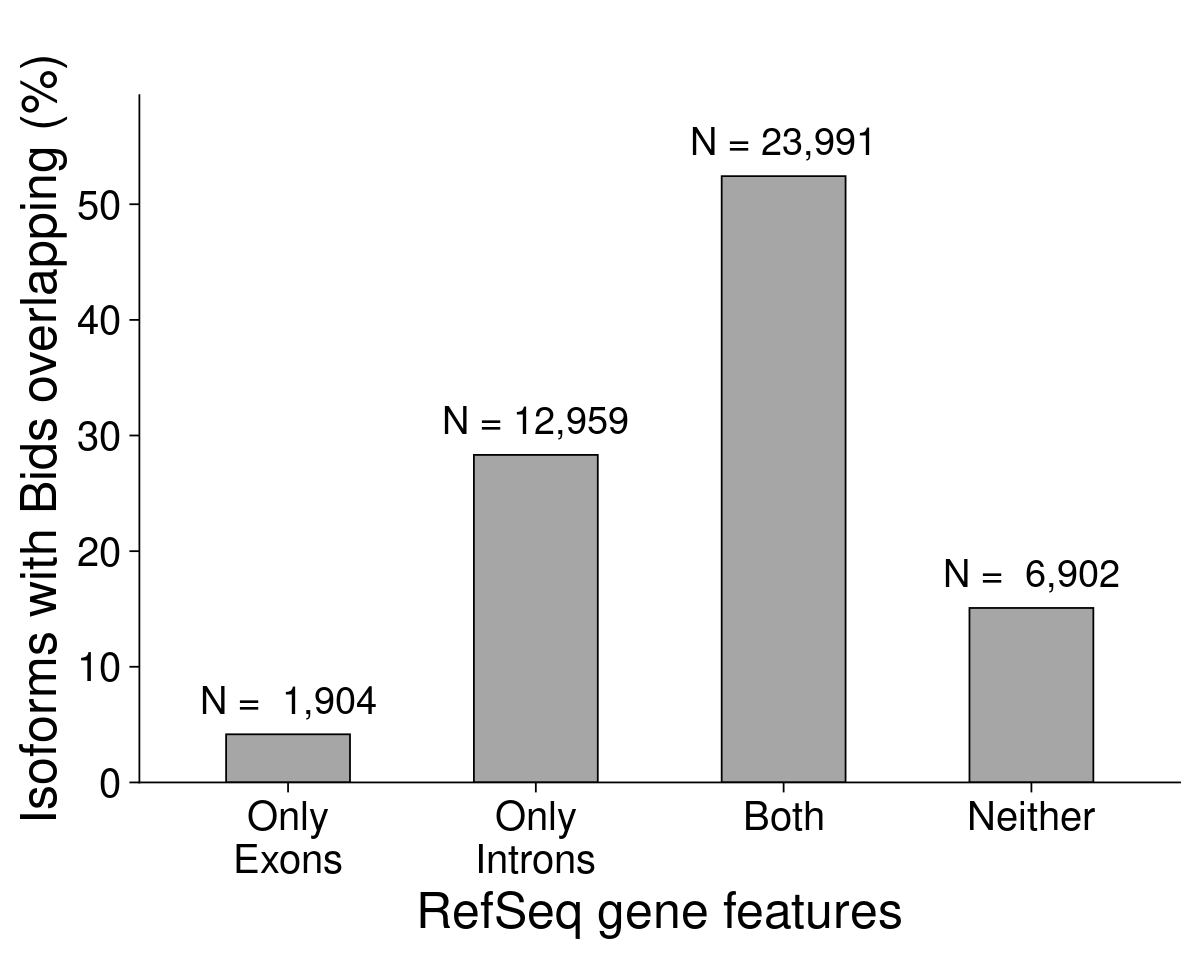

In [29]:

options(repr.plot.width=10, repr.plot.height=8)
data_use = ie_table[ie_table$Genome=="mm10" & ie_table$Gene_Metric=="Isoform",]
# Get the numbers to plot
rownames(data_use) <- data_use$Category
percs_plot = data_use[x_order,]$Per_Transcripts + 3
nums_plot = data_use[x_order,]$Number 
notss_isof_bid_overlap_mm10_noheader <- ggplot2::ggplot(data_use,
       aes(x=factor(Category, 
                    levels=x_order), y=as.numeric(Per_Transcripts))) +
geom_bar(stat="identity", width=0.5, color='black',fill="gray65")+
  scale_y_continuous(expand = c(0, 0)) +
labs(title=" ",
     x="RefSeq gene features", 
     y = "Isoforms with Bids overlapping (%)") + #"% of bidirectionals overlapping")+
annotate("text", x=c(1,2,3,4),
         y=percs_plot, 
         label= paste("N =", format(nums_plot, 
       scientific = FALSE, big.mark = ',')), size = 8) + 
theme_cowplot(24) +
coord_cartesian(ylim=c(0, max(percs_plot)+4)) +
theme(plot.title = element_text(hjust = 0.5),
      title = element_text(size = 30), 
      axis.title = element_text(size = 30), 
      axis.text = element_text(size = 24),
     axis.text.x = element_text(size = 24),
     legend.position="none") 

notss_isof_bid_overlap_mm10_noheader

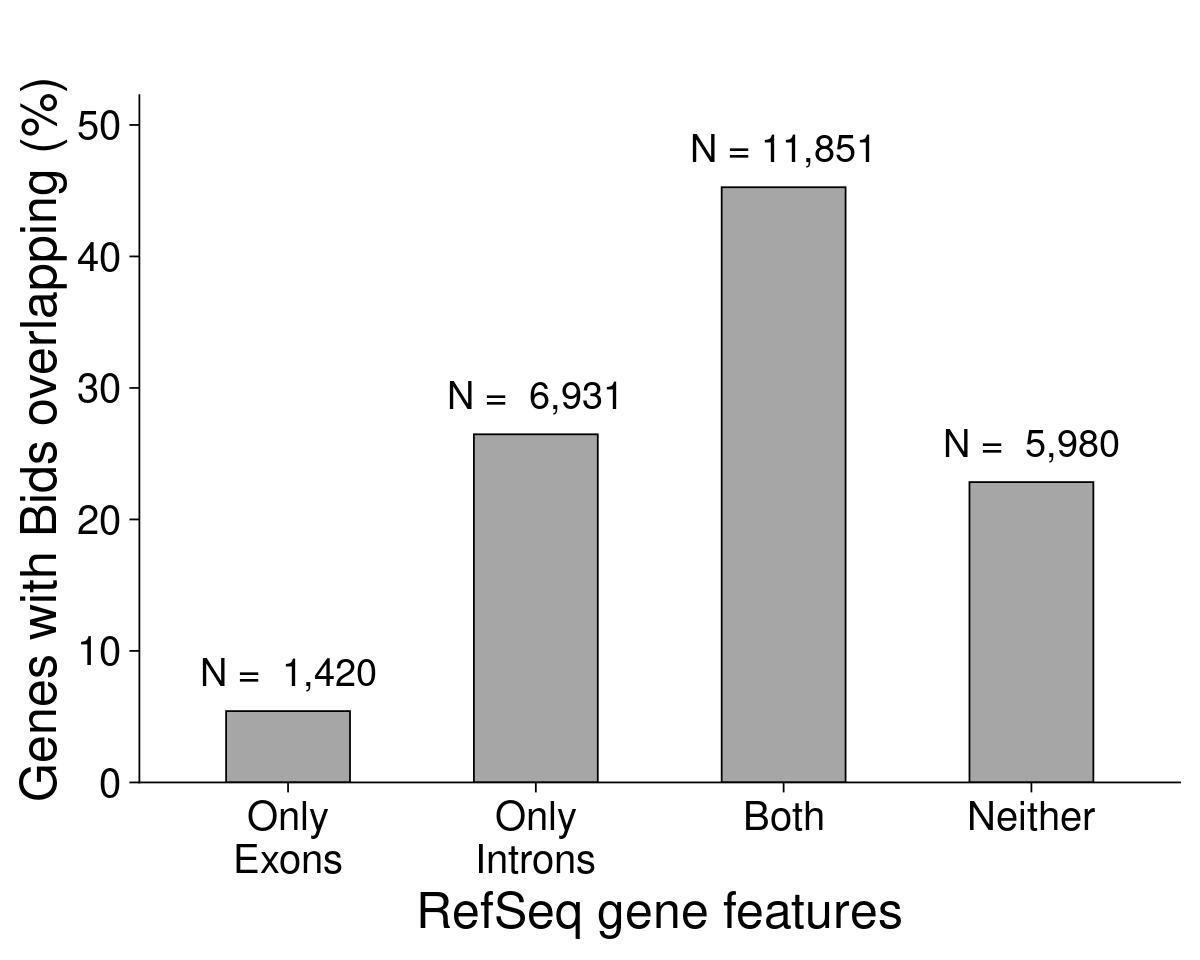

In [30]:

options(repr.plot.width=10, repr.plot.height=8)
data_use = ie_table[ie_table$Genome=="mm10" & ie_table$Gene_Metric=="Gene",]
# Get the numbers to plot
rownames(data_use) <- data_use$Category
percs_plot = data_use[x_order,]$Per_Transcripts + 3
nums_plot = data_use[x_order,]$Number 
notss_gene_bid_overlap_mm10_noheader <- ggplot2::ggplot(data_use,
       aes(x=factor(Category, 
                    levels=x_order), y=as.numeric(Per_Transcripts))) +
geom_bar(stat="identity", width=0.5, color='black',fill="gray65")+
  scale_y_continuous(expand = c(0, 0)) +
labs(title=" ",
     x="RefSeq gene features", 
     y = "Genes with Bids overlapping (%)") + #"% of bidirectionals overlapping")+
annotate("text", x=c(1,2,3,4),
         y=percs_plot, 
         label= paste("N =", format(nums_plot, 
       scientific = FALSE, big.mark = ',')), size = 8) + 
theme_cowplot(24) +
coord_cartesian(ylim=c(0, max(percs_plot)+4)) +
theme(plot.title = element_text(hjust = 0.5),
      title = element_text(size = 30), 
      axis.title = element_text(size = 30), 
      axis.text = element_text(size = 24),
     axis.text.x = element_text(size = 24),
     legend.position="none") 

notss_gene_bid_overlap_mm10_noheader

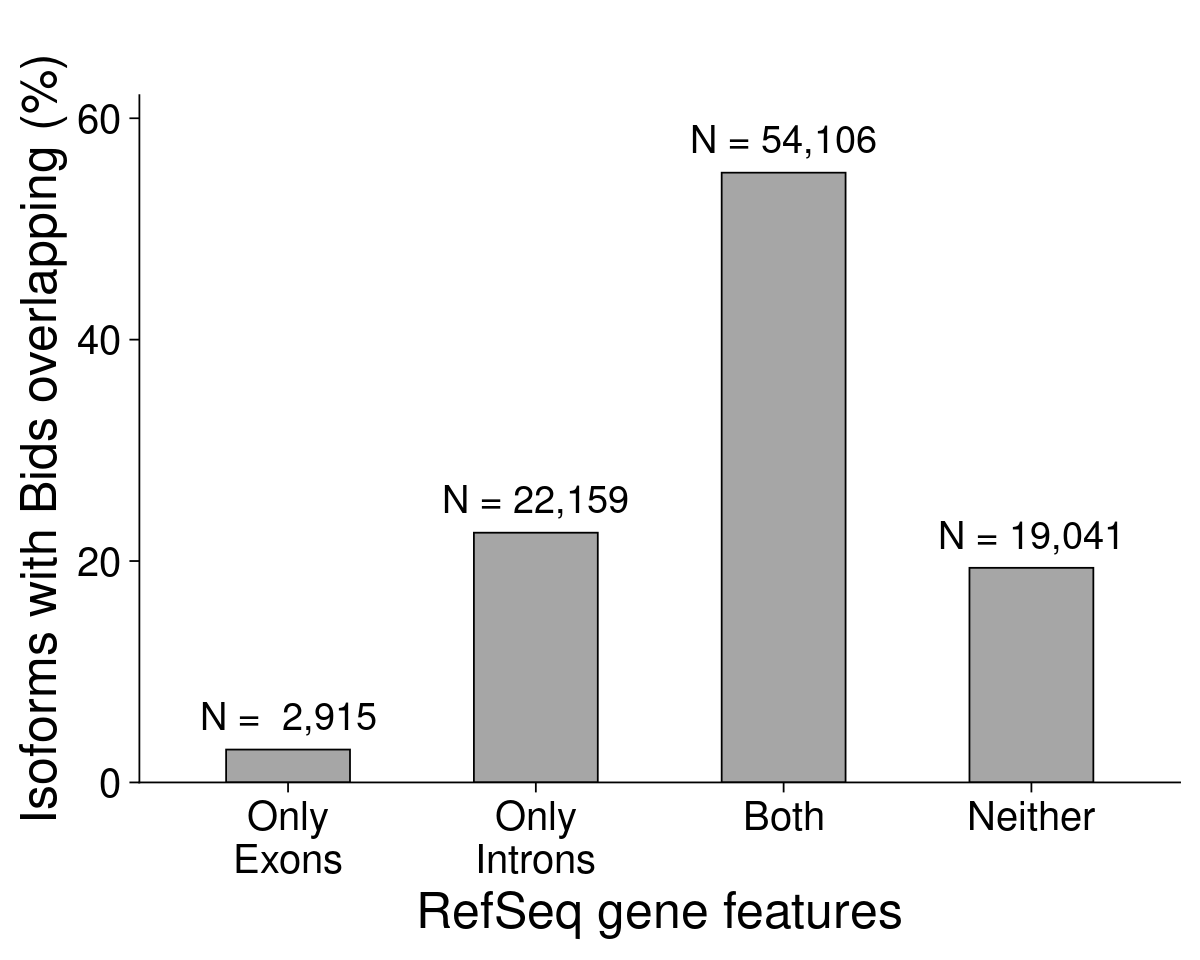

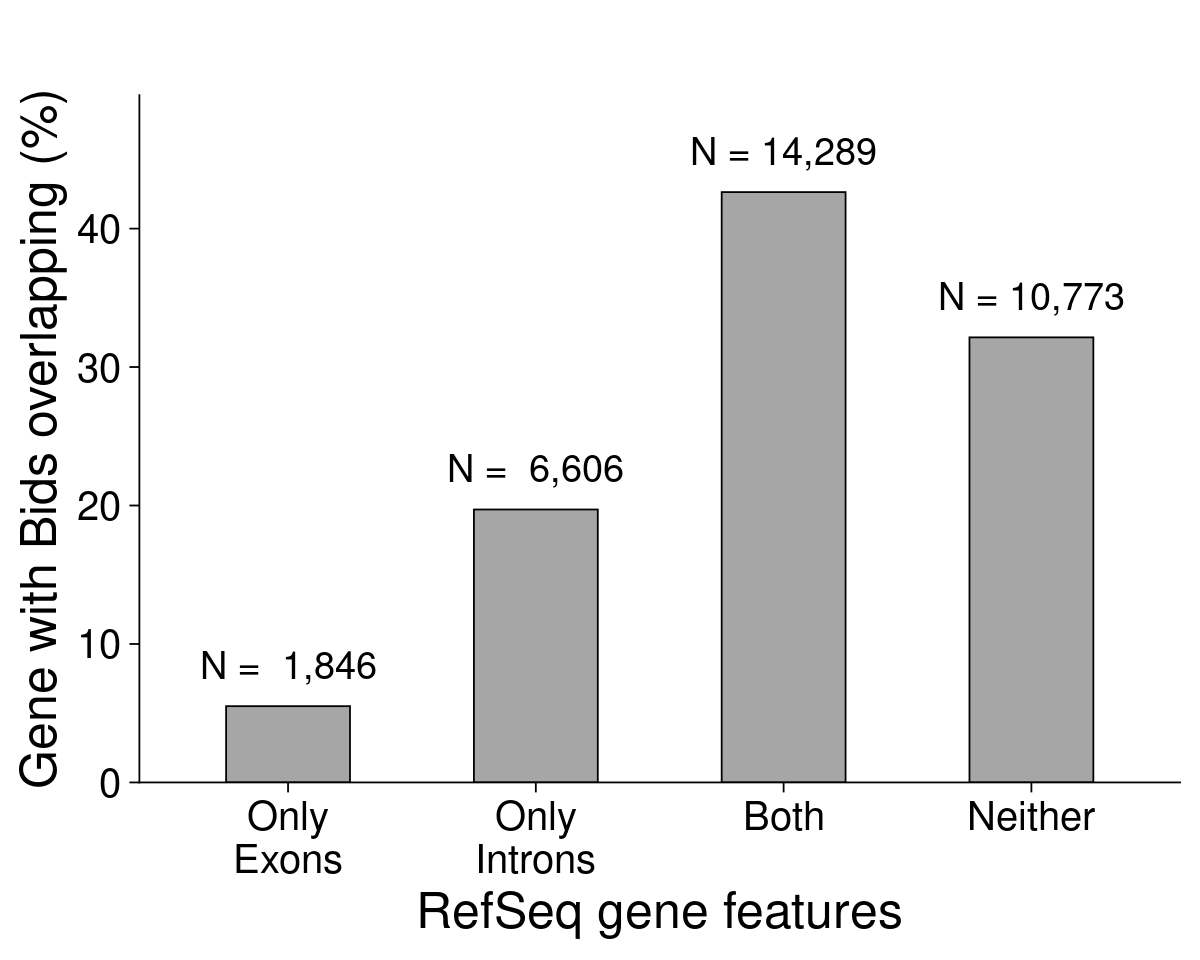

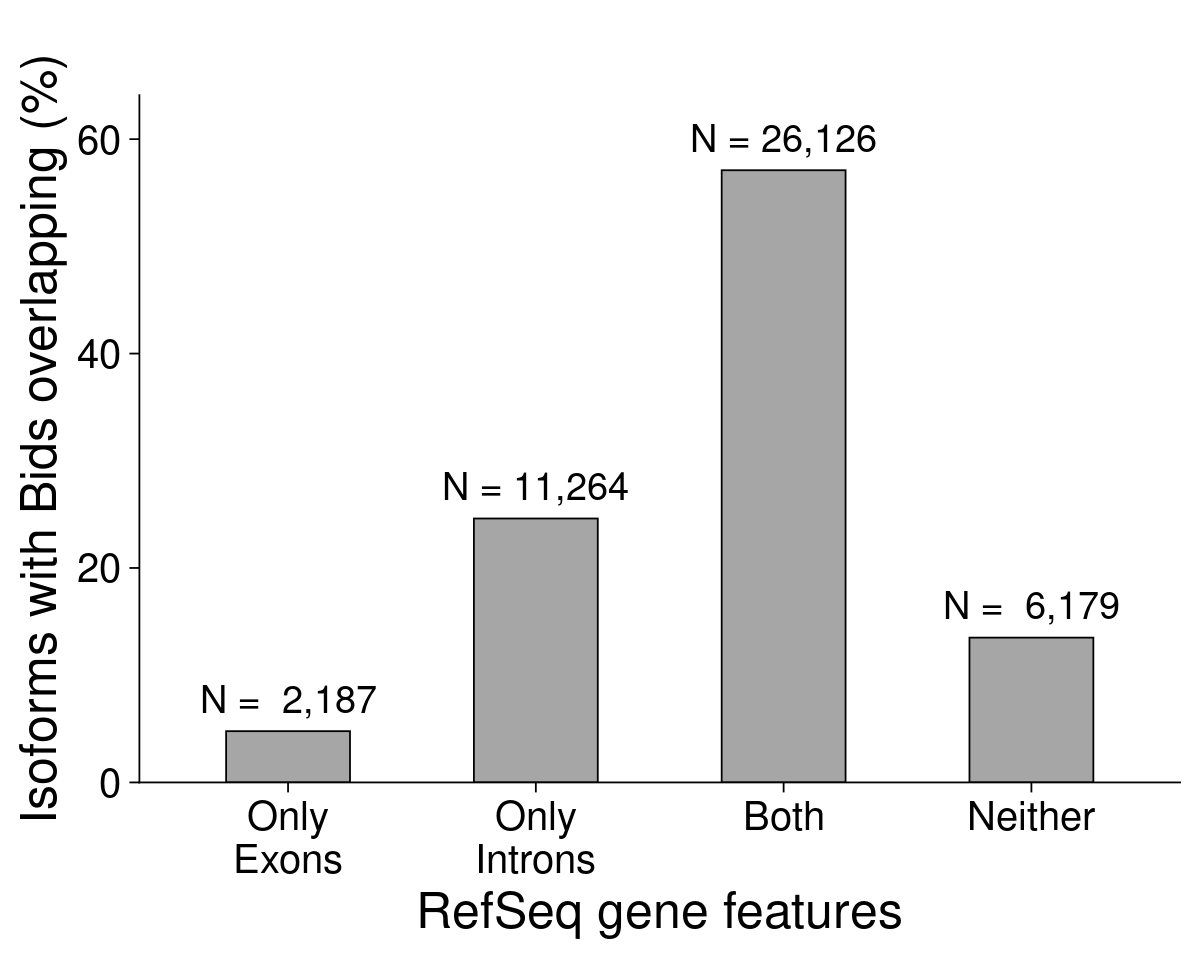

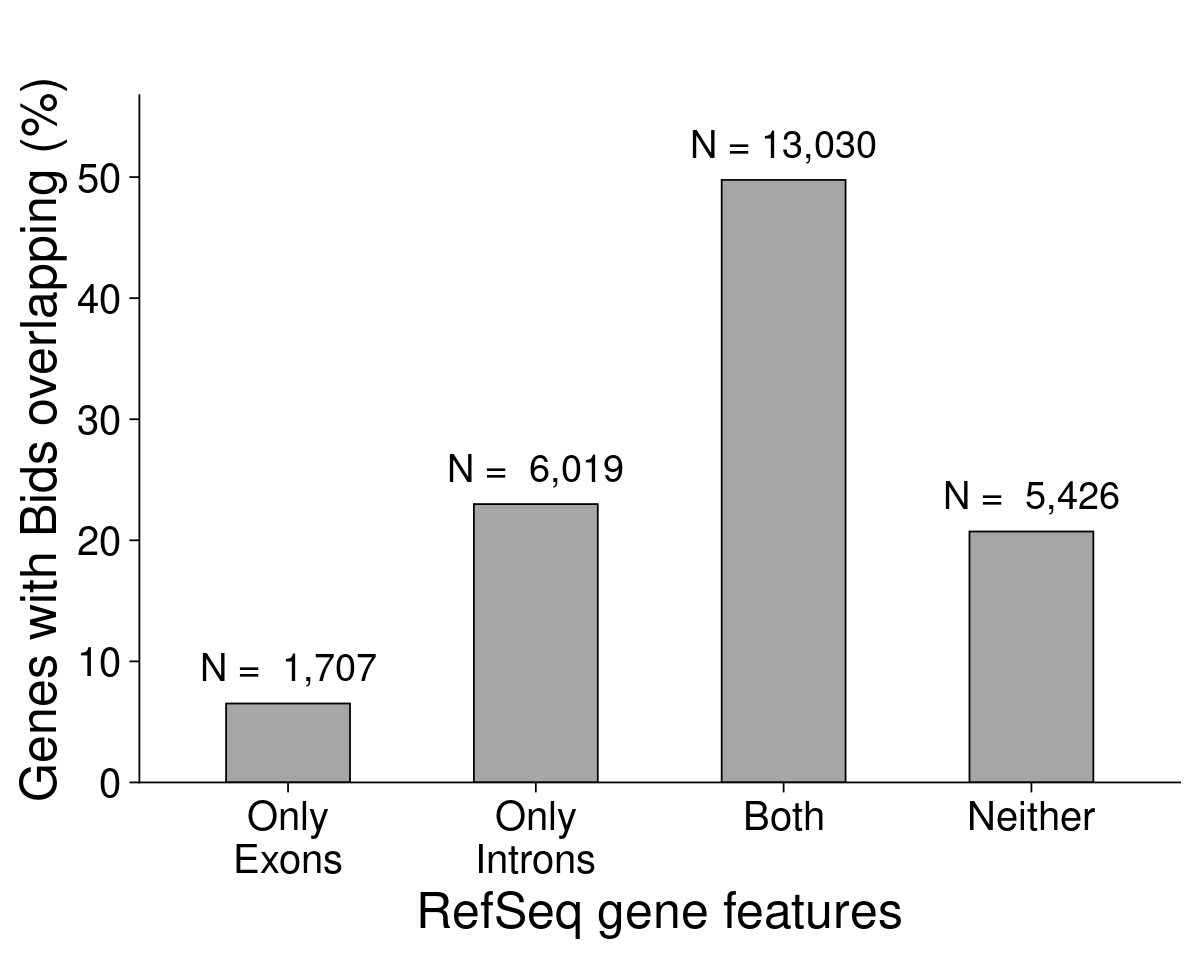

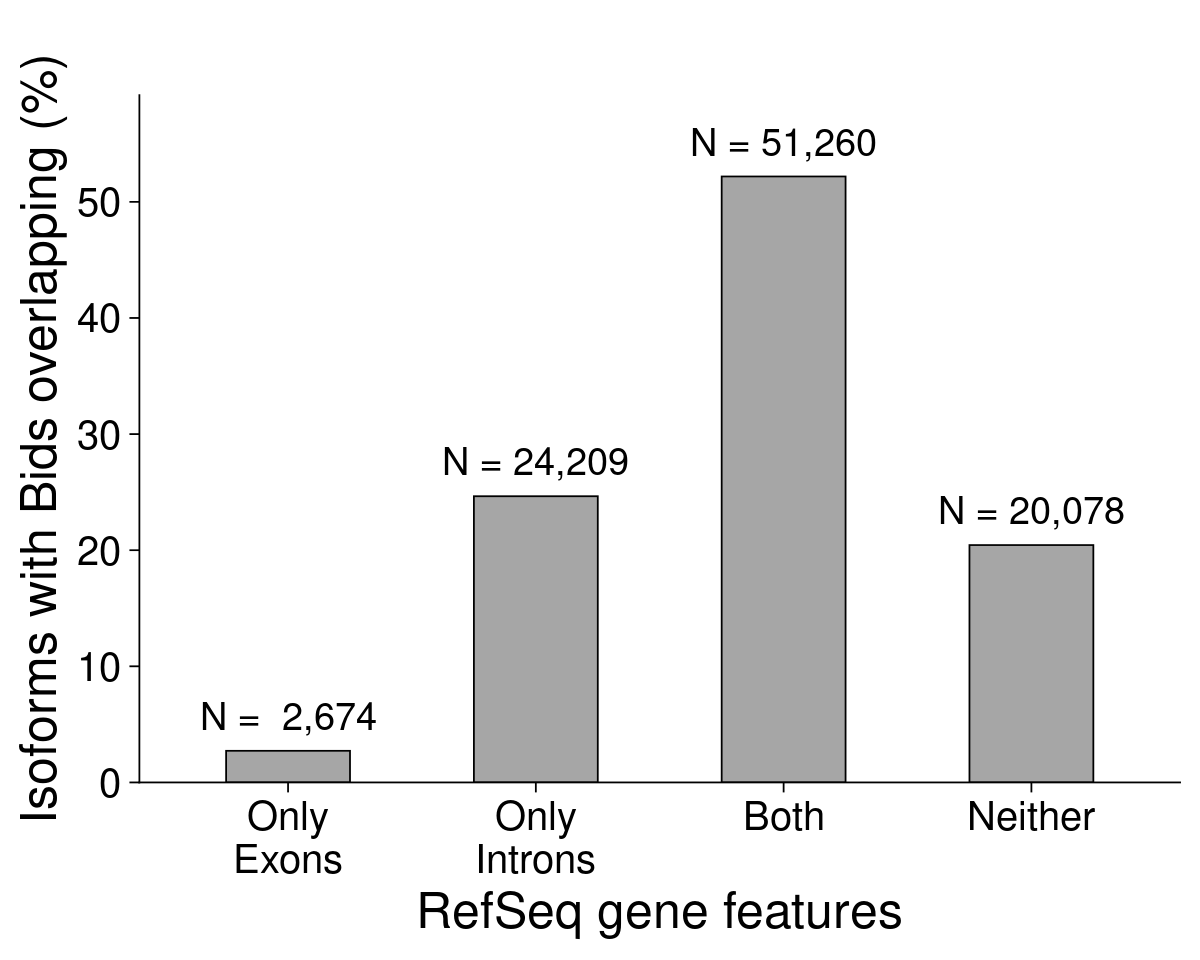

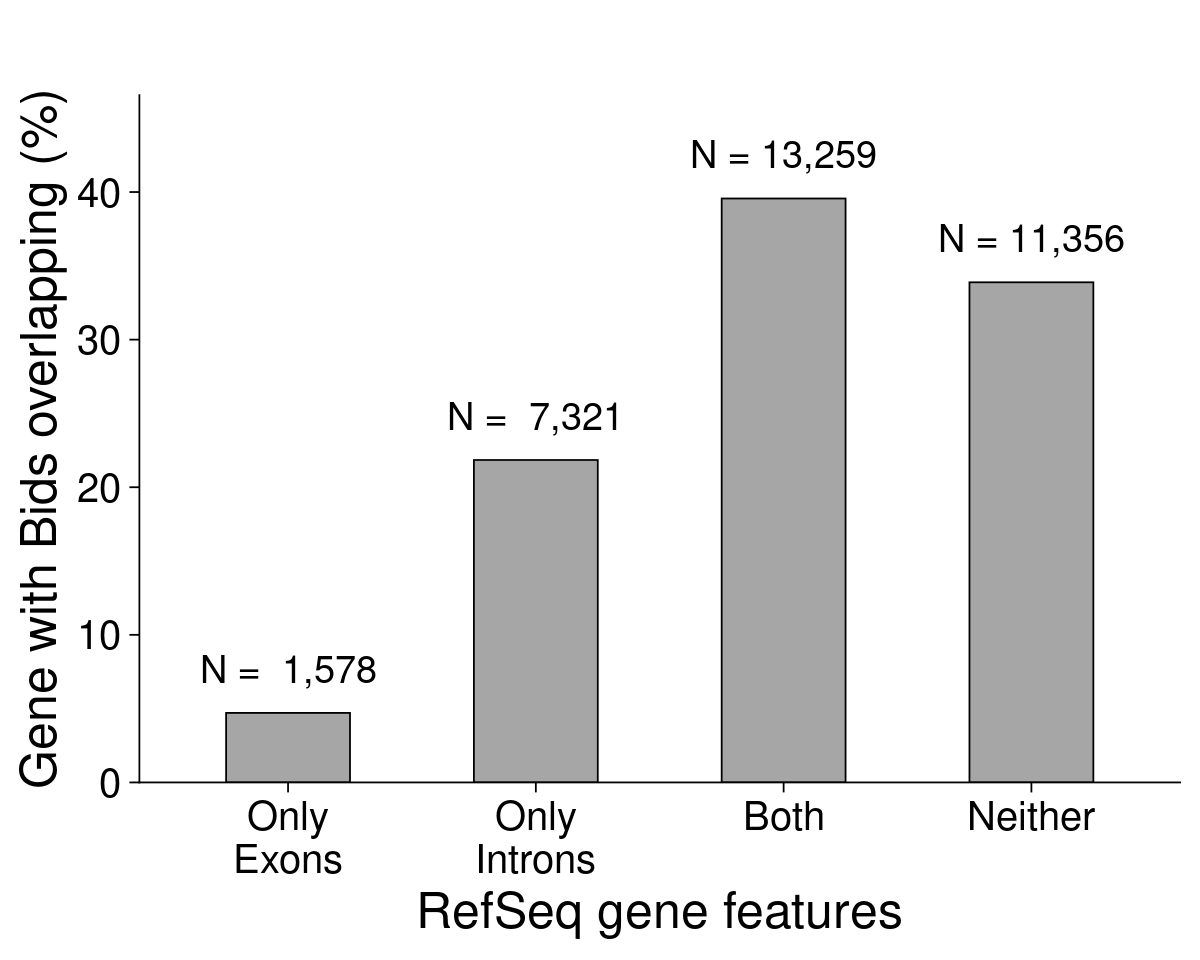

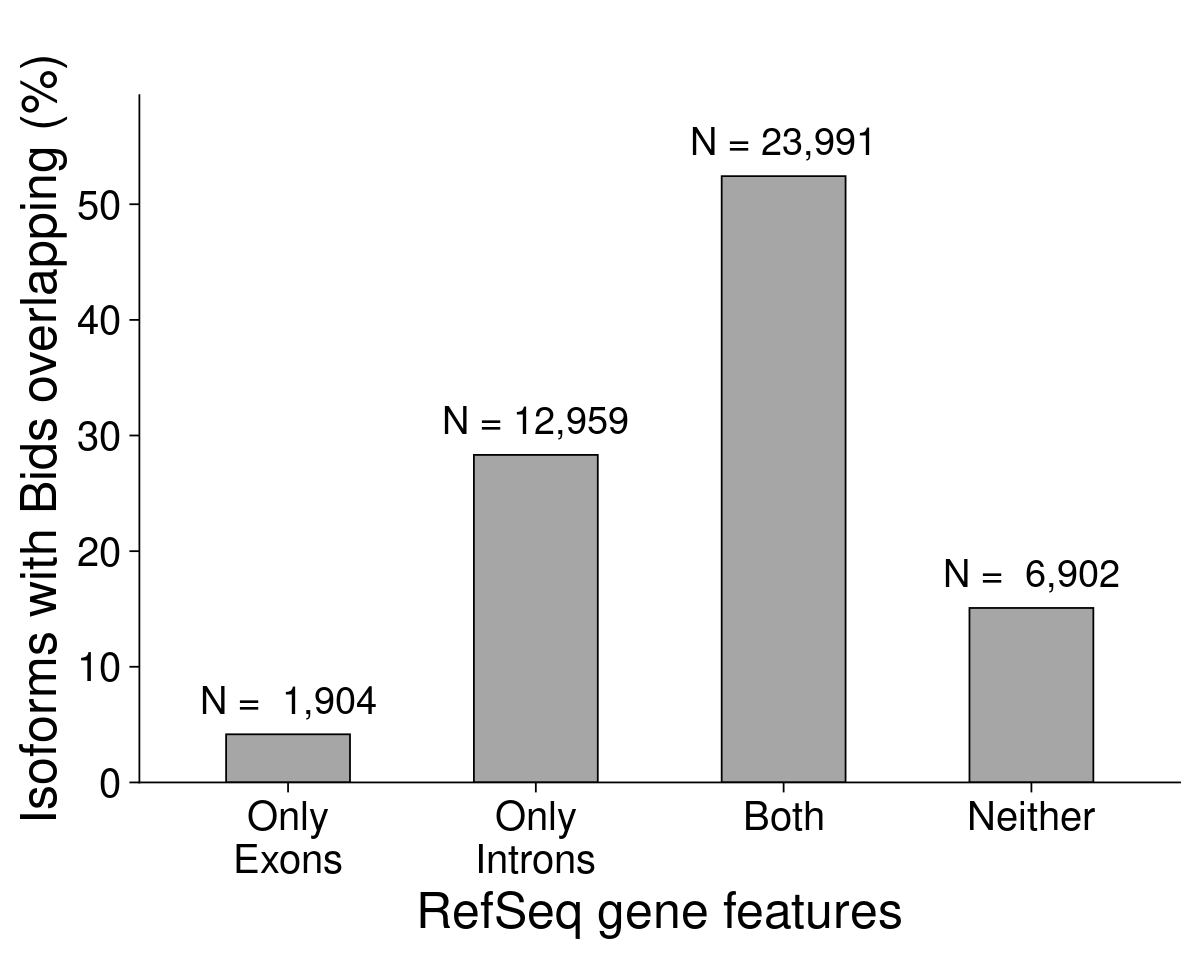

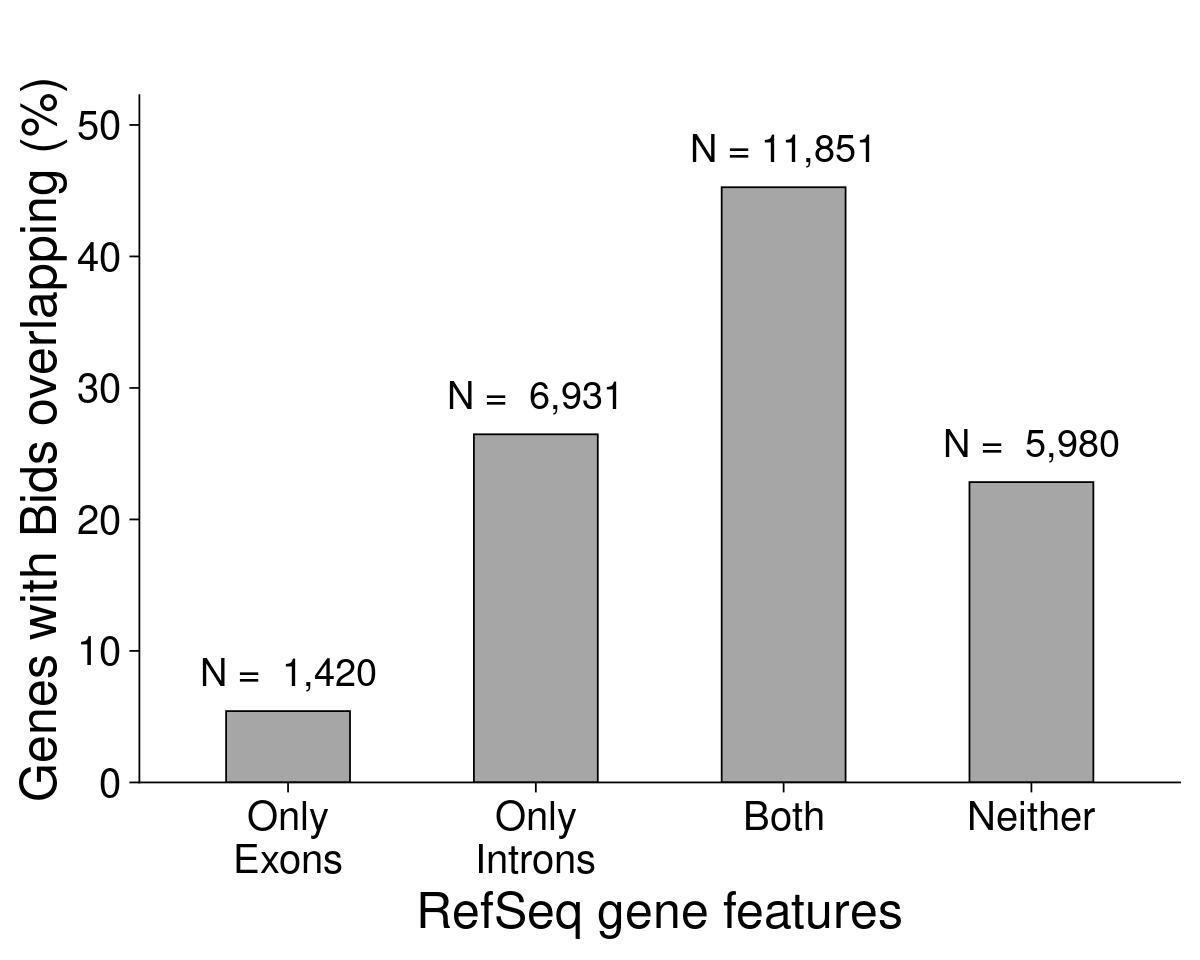

In [31]:
isof_bid_overlap_hg38_noheader
gene_bid_overlap_hg38_noheader
isof_bid_overlap_mm10_noheader
gene_bid_overlap_mm10_noheader

notss_isof_bid_overlap_hg38_noheader
notss_gene_bid_overlap_hg38_noheader
notss_isof_bid_overlap_mm10_noheader
notss_gene_bid_overlap_mm10_noheader

In [32]:


ggsave(notss_isof_bid_overlap_hg38_noheader, width = 10, height = 8,
       filename = "/Users/hoto7260/projects/For_others/paper_figures/hg38_geneISOF_refseq_overlap_bids_notss.pdf", 
       bg = "transparent")
ggsave(notss_gene_bid_overlap_hg38_noheader, width = 10, height = 8,
       filename = "/Users/hoto7260/projects/For_others/paper_figures/hg38_gene_refseq_overlap_bids_notss.pdf", 
       bg = "transparent")
ggsave(notss_isof_bid_overlap_mm10_noheader, width = 10, height = 8,
       filename = "/Users/hoto7260/projects/For_others/paper_figures/mm10_geneISOF_refseq_overlap_bids_notss.pdf", 
       bg = "transparent")
ggsave(notss_gene_bid_overlap_mm10_noheader, width = 10, height = 8,
       filename = "/Users/hoto7260/projects/For_others/paper_figures/mm10_gene_refseq_overlap_bids_notss.pdf", 
       bg = "transparent")

## 3. Zooming in on exonic features
* Note: As specified in the linked [notebook](https://github.com/Dowell-Lab/DBNascent_Analysis/blob/main/notebooks/03_bidirectionals_genome_feature_overlap.ipynb), these annotations are used from UCSC and therefore might have *slight* differences in exons (as shown below not significant)

In [ ]:
!#/bin/bash
RDIR=/scratch/Shares/dowell/rutendo/annotations/refseq_gtfs
mm10_features=${RDIR}/mm10.ncbiRefSeq.gtf
hg38_features=${RDIR}/hg38.ncbiRefSeq.gtf
mumerge=/scratch/Shares/dowell/dbnascent/out/meta_analysis/mumerge/bidirectionals_dreg_tfit
hg38_mumerge=${mumerge}/hg38_tfit_dreg_bidirectionals.bed
mm10_mumerge=${mumerge}/mm10_tfit_dreg_bidirectionals.bed
out=/scratch/Users/hoto7260/Bidir_Analysis/overlaps

##get overlap for annotations
# Using **curated** gene annotations (NM,NR,NP) as specificed here : https://genome.ucsc.edu/cgi-bin/hgTrackUi?db=hg38&g=refSeqComposite&position=default
for feature in `cat ${hg38_features} | cut -f 3 | sort | uniq | grep -w '5UTR\|3UTR\|CDS\|exon'`; do
    echo $feature
    #human
    cat ${hg38_features} | grep -w ${feature} | \
        grep "NM_\|NR_\|NP_" | \
	bedtools intersect -a ${hg38_mumerge} -b - -wo -f 0.5 > ${out}/hg38_${feature}.mumerge_overlap50perc.bed

    #mouse
    cat ${mm10_features} | grep -w ${feature} | \
	grep "NM_\|NR_\|NP_" | \
	bedtools intersect -a ${mm10_mumerge} -b - -wo -f 0.5 > ${out}/mm10_${feature}.mumerge_overlap50perc.bed
    
done


In [33]:
hg38_trans$TransID <- str_split_fixed(hg38_trans$V4, ":", 2)[,2]
mm10_trans$TransID <- str_split_fixed(mm10_trans$V4, ":", 2)[,2]
hg38_trans[1:2,]
mm10_trans[1:2,]

V1,V2,V3,V4,V5,V6,TSS,Gene,TransID
<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>
chr1,11873,14409,DDX11L1:NR_046018.2,.,+,11873,DDX11L1,NR_046018.2
chr1,14361,29370,WASH7P:NR_024540.1,.,-,14361,WASH7P,NR_024540.1


V1,V2,V3,V4,V5,V6,TSS,start,stop,Gene,TransID
<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>
chr1,3214481,3671498,Xkr4:NM_001011874.1,.,-,3671498,3670998,3671998,Xkr4,NM_001011874.1
chr1,4119865,4360303,Rp1:NM_001370921.1,.,-,4360303,4359803,4360803,Rp1,NM_001370921.1


In [34]:
get_ids <- function(over_file) {
    over_file = fread(over_file)
    split = str_split_fixed(over_file$V15, ";", 5)
    over_file$TransID = str_split_fixed(split[,2], '"', 3)[,2]
    over_file$Gene = str_split_fixed(split[,1], '"', 3)[,2]
    over_file$V15 = paste0(over_file$Gene, ":", over_file$TransID)
    over_file$mu <- as.integer((over_file$V2 + over_file$V3)/2)
    over_file$name <- paste0(over_file$V1, ":", over_file$mu)
    return(over_file)
    }

overdir="/scratch/Shares/dowell/rutendo/projects/refseq_genome_overlap/"
overdir="/scratch/Users/hoto7260/Bidir_Analysis/overlaps/"
hg38_over_exons <- get_ids(paste0(overdir, "hg38_5UTR.mumerge_overlap50perc.bed"))
hg38_over_5utr <- get_ids(paste0(overdir, "hg38_5UTR.mumerge_overlap50perc.bed"))
hg38_over_3utr <- get_ids(paste0(overdir, "hg38_3UTR.mumerge_overlap50perc.bed"))
hg38_over_cds <- get_ids(paste0(overdir, "hg38_CDS.mumerge_overlap50perc.bed"))
hg38_over_5utr[1:4,]

mm10_over_exons <- get_ids(paste0(overdir, "mm10_exon.mumerge_overlap50perc.bed"))
mm10_over_5utr <- get_ids(paste0(overdir, "mm10_5UTR.mumerge_overlap50perc.bed"))
mm10_over_3utr <- get_ids(paste0(overdir, "mm10_3UTR.mumerge_overlap50perc.bed"))
mm10_over_cds <- get_ids(paste0(overdir, "mm10_CDS.mumerge_overlap50perc.bed"))
mm10_over_exons[1:2,]

V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,TransID,Gene,mu,name
<chr>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>
chr1,1034163,1034483,tfit,31,.,chr1,ncbiRefSeq.2022-10-28,5UTR,1033993,1034555,.,+,.,AGRN:NM_001364727.2,320,NM_001364727.2,AGRN,1034323,chr1:1034323
chr1,1074193,1074407,"tfit,dreg",153,.,chr1,ncbiRefSeq.2022-10-28,5UTR,1074016,1074306,.,-,.,RNF223:NM_001205252.2,113,NM_001205252.2,RNF223,1074300,chr1:1074300
chr1,1280366,1280634,tfit,50,.,chr1,ncbiRefSeq.2022-10-28,5UTR,1280436,1280661,.,+,.,SCNN1D:NM_001130413.4,199,NM_001130413.4,SCNN1D,1280500,chr1:1280500
chr1,1361224,1361618,dreg,2,.,chr1,ncbiRefSeq.2022-10-28,5UTR,1361264,1361799,.,-,.,MXRA8:NM_001282583.2,355,NM_001282583.2,MXRA8,1361421,chr1:1361421


V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,TransID,Gene,mu,name
<chr>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>
chr1,3670923,3671237,tfit,23,.,chr1,ncbiRefSeq.2021-04-23,exon,3670552,3671498,.,-,.,Xkr4:NM_001011874.1,314,NM_001011874.1,Xkr4,3671080,chr1:3671080
chr1,4491470,4491746,dreg,12,.,chr1,ncbiRefSeq.2021-04-23,exon,4490928,4492668,.,-,.,Sox17:NM_011441.5,276,NM_011441.5,Sox17,4491608,chr1:4491608


#### 5'UTR, 3'UTR, CDS

In [35]:
# Get the fractions & numbers of Transcripts & Genes with:
# Bid calls in CDS
hg38_isof_cds = unique(hg38_over_cds$TransID)
hg38_gene_cds = unique(hg38_over_cds$Gene)
mm10_isof_cds = unique(mm10_over_cds$TransID)
mm10_gene_cds = unique(mm10_over_cds$Gene)
# Bid calls in 5'UTR
hg38_isof_5utr = unique(hg38_over_5utr$TransID)
hg38_gene_5utr = unique(hg38_over_5utr$Gene)
mm10_isof_5utr = unique(mm10_over_5utr$TransID)
mm10_gene_5utr = unique(mm10_over_5utr$Gene)
# Bid calls in 3'UTR
hg38_isof_3utr = unique(hg38_over_3utr$TransID)
hg38_gene_3utr = unique(hg38_over_3utr$Gene)
mm10_isof_3utr = unique(mm10_over_3utr$TransID)
mm10_gene_3utr = unique(mm10_over_3utr$Gene)
# Bid calls in all 3
hg38_isof_all = intersect(hg38_isof_cds, intersect(hg38_isof_5utr, hg38_isof_3utr))
hg38_gene_all = intersect(hg38_gene_cds, intersect(hg38_gene_5utr, hg38_gene_3utr))
mm10_isof_all = intersect(mm10_isof_cds, intersect(mm10_isof_5utr, mm10_isof_3utr))
mm10_gene_all = intersect(mm10_gene_cds, intersect(mm10_gene_5utr, mm10_gene_3utr))
# Bid calls in Any
hg38_isof_any = union(hg38_isof_cds, union(hg38_isof_5utr, hg38_isof_3utr))
hg38_gene_any = union(hg38_gene_cds, union(hg38_gene_5utr, hg38_gene_3utr))
mm10_isof_any = union(mm10_isof_cds, union(mm10_isof_5utr, mm10_isof_3utr))
mm10_gene_any = union(mm10_gene_cds, union(mm10_gene_5utr, mm10_gene_3utr))
length(mm10_isof_any)
length(mm10_gene_any)
length(unique(mm10_trans$TransID))
# Bid calls in none
hg38_isof_none = setdiff(hg38_trans$TransID, hg38_isof_any)
hg38_gene_none = setdiff(hg38_trans$Gene, hg38_gene_any)
mm10_isof_none = setdiff(mm10_trans$TransID, mm10_isof_any)
mm10_gene_none = setdiff(mm10_trans$Gene, mm10_gene_any)

[1] 24109

[1] 12665

[1] 45756

In [36]:
# table with fraction and number
ie_table <- as.data.frame(data.table("Genome"=c(rep("hg38",10), rep("mm10", 10)),
                       "Gene_Metric"=rep(c("Isoform", "Gene"), 10),
                      "Category"=rep(c("5UTR", "5UTR",
                                         "CDS", "CDS",
                                         "3UTR", "3UTR", 
                                         "None", "None", 
                                      "All", "All"),2), 
                       "Number"=c(length(hg38_isof_5utr), length(hg38_gene_5utr), 
                                 length(hg38_isof_cds), length(hg38_gene_cds),
                                  length(hg38_isof_3utr), length(hg38_gene_3utr), 
                                 length(hg38_isof_none), length(hg38_gene_none), 
                                  length(hg38_isof_all), length(hg38_gene_all), 
                                 length(mm10_isof_5utr), length(mm10_gene_5utr), 
                                 length(mm10_isof_cds), length(mm10_gene_cds),
                                  length(mm10_isof_3utr), length(mm10_gene_3utr), 
                                 length(mm10_isof_none), length(mm10_gene_none),
                                 length(mm10_isof_all), length(mm10_gene_all)), 
                       "Total"=c(rep(c(hg38_tot_isoforms, hg38_tot_genes), 5), 
                                rep(c(mm10_tot_isoforms, mm10_tot_genes), 5))))
ie_table$Per_Transcripts <- ie_table$Number/ie_table$Total*100
ie_table

Genome,Gene_Metric,Category,Number,Total,Per_Transcripts
<chr>,<chr>,<chr>,<int>,<int>,<dbl>
hg38,Isoform,5UTR,7580,98221,7.717291
hg38,Gene,5UTR,2892,33514,8.629230
hg38,Isoform,CDS,25172,98221,25.627921
hg38,Gene,CDS,7644,33514,22.808379
hg38,Isoform,3UTR,28939,98221,29.463149
hg38,Gene,3UTR,8566,33514,25.559468
hg38,Isoform,None,57696,98221,58.741002
hg38,Gene,None,20754,33514,61.926359
hg38,Isoform,All,1980,98221,2.015862


In [37]:
x_order= c("5UTR", "CDS", "3UTR", "All", "None")

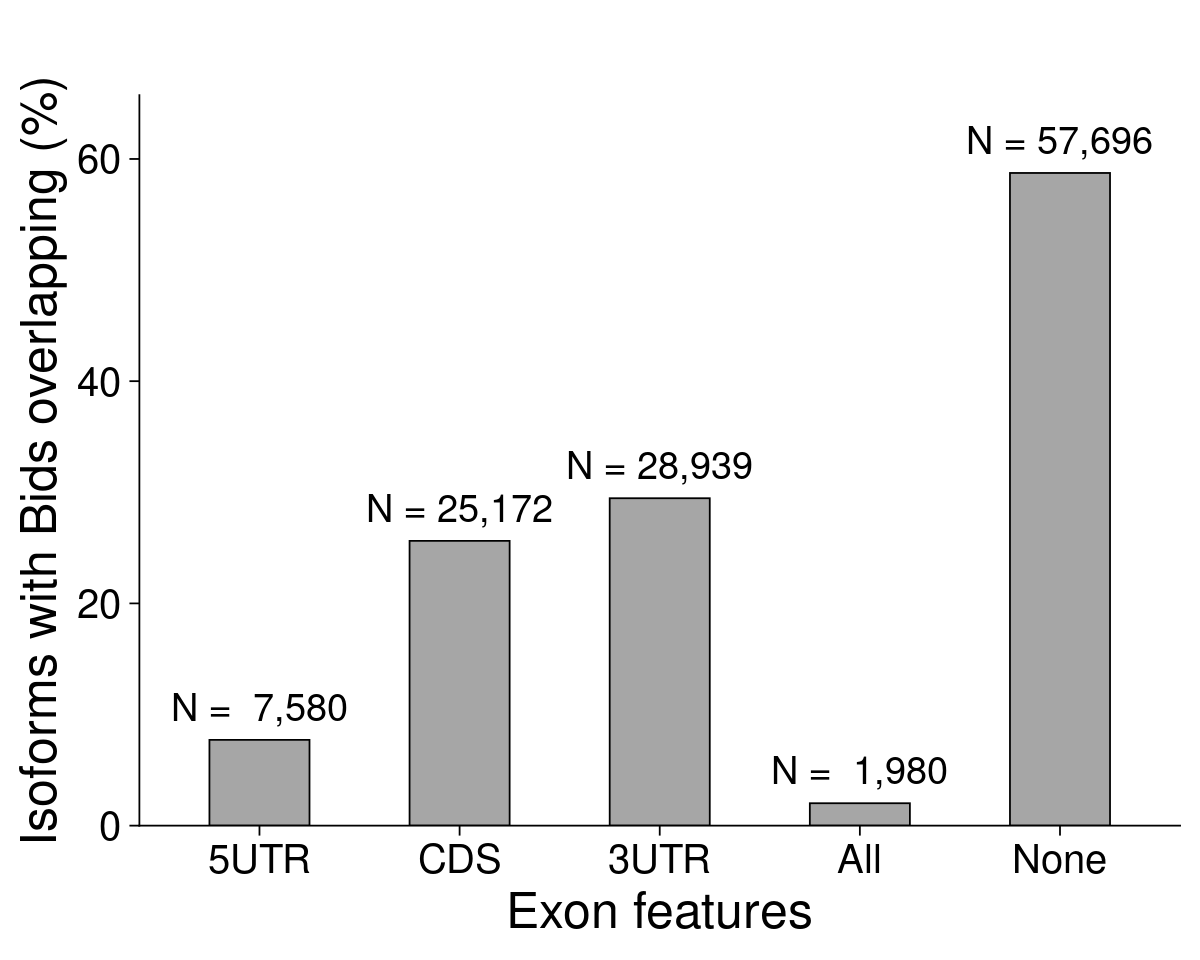

In [38]:

options(repr.plot.width=10, repr.plot.height=8)
data_use = ie_table[ie_table$Genome=="hg38" & ie_table$Gene_Metric=="Isoform",]
# Get the numbers to plot
rownames(data_use) <- data_use$Category
percs_plot = data_use[x_order,]$Per_Transcripts + 3
nums_plot = data_use[x_order,]$Number 

isof_exon_bid_overlap_hg38_noheader <- ggplot2::ggplot(data_use,
       aes(x=factor(Category, 
                    levels=x_order), y=as.numeric(Per_Transcripts))) +
geom_bar(stat="identity", width=0.5, color='black',fill="gray65")+
  scale_y_continuous(expand = c(0, 0)) +
labs(title=" ",
     x="Exon features", 
     y = "Isoforms with Bids overlapping (%)") + #"% of bidirectionals overlapping")+
annotate("text", x=c(1,2,3,4, 5),
         y=percs_plot, 
         label= paste("N =", format(nums_plot, 
       scientific = FALSE, big.mark = ',')), size = 8) + 
theme_cowplot(24) +
coord_cartesian(ylim=c(0, max(percs_plot)+4)) +
theme(plot.title = element_text(hjust = 0.5),
      title = element_text(size = 30), 
      axis.title = element_text(size = 30), 
      axis.text = element_text(size = 24),
     axis.text.x = element_text(size = 24),
     legend.position="none") 

isof_exon_bid_overlap_hg38_noheader

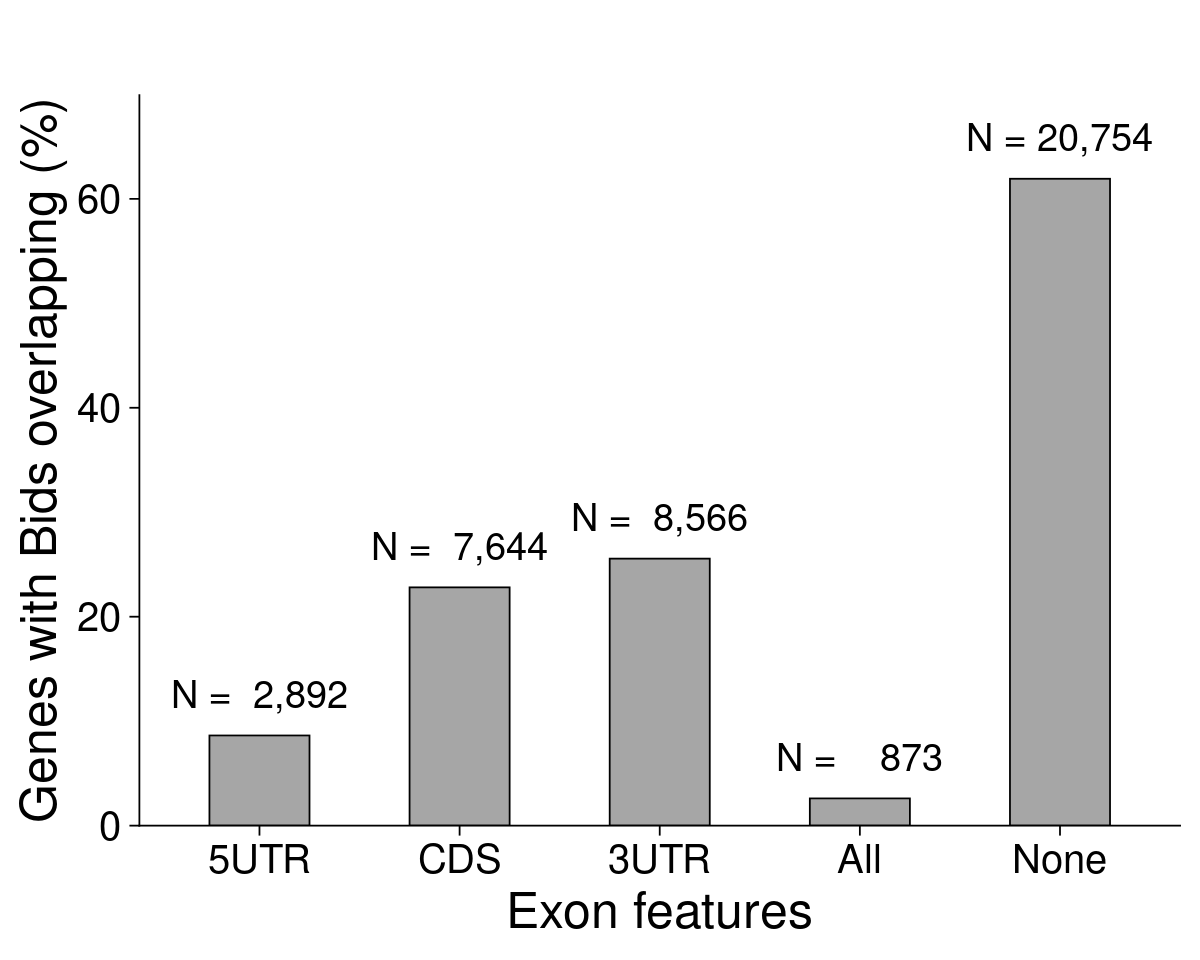

In [39]:

options(repr.plot.width=10, repr.plot.height=8)
data_use = ie_table[ie_table$Genome=="hg38" & ie_table$Gene_Metric=="Gene",]
# Get the numbers to plot
rownames(data_use) <- data_use$Category
percs_plot = data_use[x_order,]$Per_Transcripts + 4
nums_plot = data_use[x_order,]$Number 

gene_exon_bid_overlap_hg38_noheader <- ggplot2::ggplot(data_use,
       aes(x=factor(Category, 
                    levels=x_order), y=as.numeric(Per_Transcripts))) +
geom_bar(stat="identity", width=0.5, color='black',fill="gray65")+
  scale_y_continuous(expand = c(0, 0)) +
labs(title=" ",
     x="Exon features", 
     y = "Genes with Bids overlapping (%)") + #"% of bidirectionals overlapping")+
annotate("text", x=c(1,2,3,4, 5),
         y=percs_plot, 
         label= paste("N =", format(nums_plot, 
       scientific = FALSE, big.mark = ',')), size = 8) + 
theme_cowplot(24) +
coord_cartesian(ylim=c(0, max(percs_plot)+4)) +
theme(plot.title = element_text(hjust = 0.5),
      title = element_text(size = 30), 
      axis.title = element_text(size = 30), 
      axis.text = element_text(size = 24),
     axis.text.x = element_text(size = 24),
     legend.position="none") 

gene_exon_bid_overlap_hg38_noheader

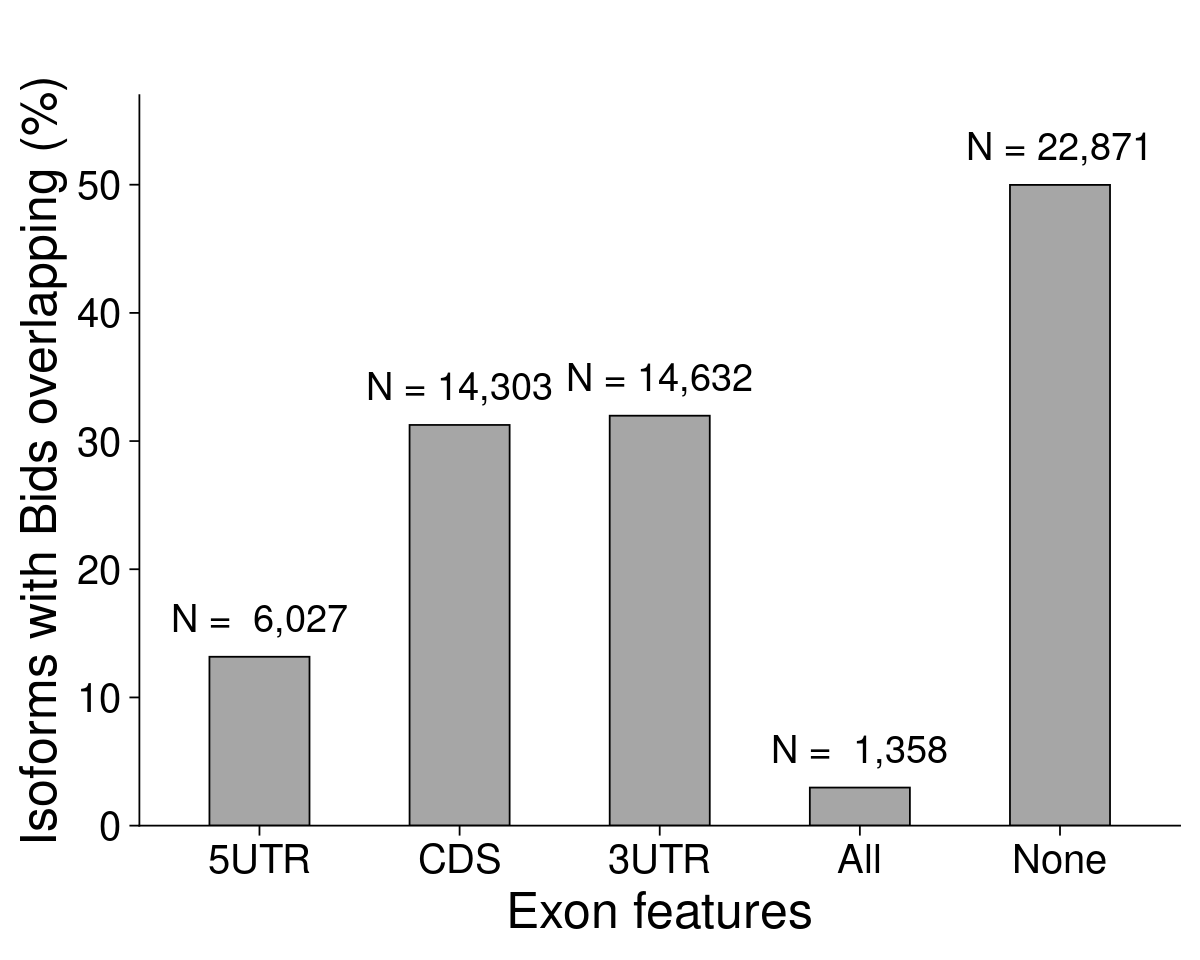

In [40]:

options(repr.plot.width=10, repr.plot.height=8)
data_use = ie_table[ie_table$Genome=="mm10" & ie_table$Gene_Metric=="Isoform",]
# Get the numbers to plot
rownames(data_use) <- data_use$Category
percs_plot = data_use[x_order,]$Per_Transcripts + 3
nums_plot = data_use[x_order,]$Number 

isof_exon_bid_overlap_mm10_noheader <- ggplot2::ggplot(data_use,
       aes(x=factor(Category, 
                    levels=x_order), y=as.numeric(Per_Transcripts))) +
geom_bar(stat="identity", width=0.5, color='black',fill="gray65")+
  scale_y_continuous(expand = c(0, 0)) +
labs(title=" ",
     x="Exon features", 
     y = "Isoforms with Bids overlapping (%)") + #"% of bidirectionals overlapping")+
annotate("text", x=c(1,2,3,4, 5),
         y=percs_plot, 
         label= paste("N =", format(nums_plot, 
       scientific = FALSE, big.mark = ',')), size = 8) + 
theme_cowplot(24) +
coord_cartesian(ylim=c(0, max(percs_plot)+4)) +
theme(plot.title = element_text(hjust = 0.5),
      title = element_text(size = 30), 
      axis.title = element_text(size = 30), 
      axis.text = element_text(size = 24),
     axis.text.x = element_text(size = 24),
     legend.position="none") 

isof_exon_bid_overlap_mm10_noheader

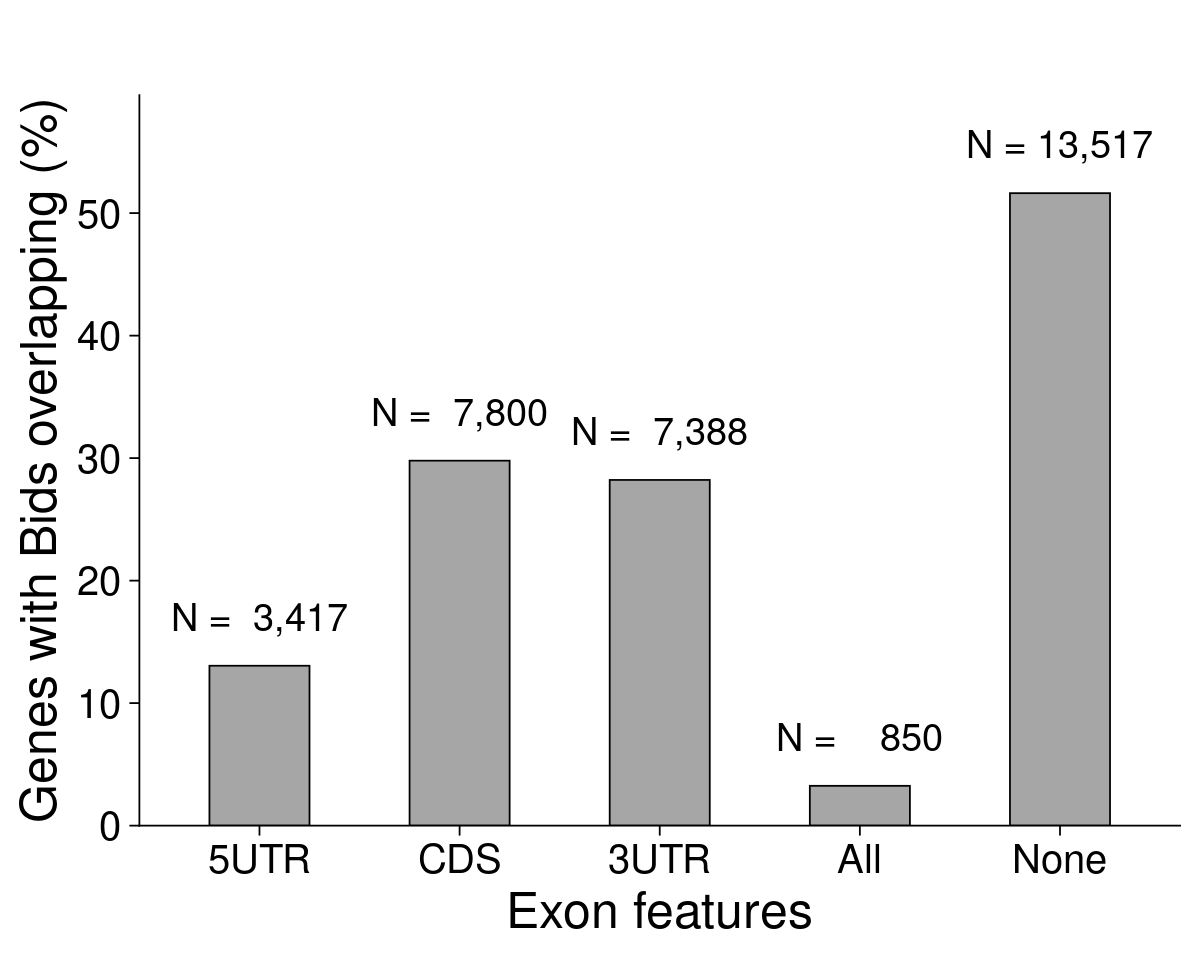

In [41]:

options(repr.plot.width=10, repr.plot.height=8)
data_use = ie_table[ie_table$Genome=="mm10" & ie_table$Gene_Metric=="Gene",]
# Get the numbers to plot
rownames(data_use) <- data_use$Category
percs_plot = data_use[x_order,]$Per_Transcripts + 4
nums_plot = data_use[x_order,]$Number 

gene_exon_bid_overlap_mm10_noheader <- ggplot2::ggplot(data_use,
       aes(x=factor(Category, 
                    levels=x_order), y=as.numeric(Per_Transcripts))) +
geom_bar(stat="identity", width=0.5, color='black',fill="gray65")+
  scale_y_continuous(expand = c(0, 0)) +
labs(title=" ",
     x="Exon features", 
     y = "Genes with Bids overlapping (%)") + #"% of bidirectionals overlapping")+
annotate("text", x=c(1,2,3,4, 5),
         y=percs_plot, 
         label= paste("N =", format(nums_plot, 
       scientific = FALSE, big.mark = ',')), size = 8) + 
theme_cowplot(24) +
coord_cartesian(ylim=c(0, max(percs_plot)+4)) +
theme(plot.title = element_text(hjust = 0.5),
      title = element_text(size = 30), 
      axis.title = element_text(size = 30), 
      axis.text = element_text(size = 24),
     axis.text.x = element_text(size = 24),
     legend.position="none") 

gene_exon_bid_overlap_mm10_noheader

In [42]:
ggsave(isof_exon_bid_overlap_hg38_noheader, width = 10, height = 8,
       filename = "/Users/hoto7260/projects/For_others/paper_figures/hg38_geneISOF_exon_refseq_overlap_bids.pdf", 
       bg = "transparent")
ggsave(gene_exon_bid_overlap_hg38_noheader, width = 10, height = 8,
       filename = "/Users/hoto7260/projects/For_others/paper_figures/hg38_gene_exon_refseq_overlap_bids.pdf", 
       bg = "transparent")
ggsave(isof_exon_bid_overlap_mm10_noheader, width = 10, height = 8,
       filename = "/Users/hoto7260/projects/For_others/paper_figures/mm10_geneISOF_exon_refseq_overlap_bids.pdf", 
       bg = "transparent")
ggsave(gene_exon_bid_overlap_mm10_noheader, width = 10, height = 8,
       filename = "/Users/hoto7260/projects/For_others/paper_figures/mm10_gene_exon_refseq_overlap_bids.pdf", 
       bg = "transparent")

### TSS Bids not included

In [43]:
# Filter so TSS Bids no longer count
hg38_over_cds <- hg38_over_cds[!hg38_over_cds$name %in% hg38_tss_filt$name,]
hg38_over_5utr <- hg38_over_5utr[!hg38_over_5utr$name %in% hg38_tss_filt$name,]
hg38_over_3utr <- hg38_over_3utr[!hg38_over_3utr$name %in% hg38_tss_filt$name,]
mm10_over_cds <- mm10_over_cds[!mm10_over_cds$name %in% mm10_tss_filt$name,]
mm10_over_5utr <- mm10_over_5utr[!mm10_over_5utr$name %in% mm10_tss_filt$name,]
mm10_over_3utr <- mm10_over_3utr[!mm10_over_3utr$name %in% mm10_tss_filt$name,]


In [44]:
# Get the fractions & numbers of Transcripts & Genes with:
# Bid calls in CDS
hg38_isof_cds = unique(hg38_over_cds$TransID)
hg38_gene_cds = unique(hg38_over_cds$Gene)
mm10_isof_cds = unique(mm10_over_cds$TransID)
mm10_gene_cds = unique(mm10_over_cds$Gene)
# Bid calls in 5'UTR
hg38_isof_5utr = unique(hg38_over_5utr$TransID)
hg38_gene_5utr = unique(hg38_over_5utr$Gene)
mm10_isof_5utr = unique(mm10_over_5utr$TransID)
mm10_gene_5utr = unique(mm10_over_5utr$Gene)
# Bid calls in 3'UTR
hg38_isof_3utr = unique(hg38_over_3utr$TransID)
hg38_gene_3utr = unique(hg38_over_3utr$Gene)
mm10_isof_3utr = unique(mm10_over_3utr$TransID)
mm10_gene_3utr = unique(mm10_over_3utr$Gene)
# Bid calls in all 3
hg38_isof_all = intersect(hg38_isof_cds, intersect(hg38_isof_5utr, hg38_isof_3utr))
hg38_gene_all = intersect(hg38_gene_cds, intersect(hg38_gene_5utr, hg38_gene_3utr))
mm10_isof_all = intersect(mm10_isof_cds, intersect(mm10_isof_5utr, mm10_isof_3utr))
mm10_gene_all = intersect(mm10_gene_cds, intersect(mm10_gene_5utr, mm10_gene_3utr))
# Bid calls in Any
hg38_isof_any = union(hg38_isof_cds, union(hg38_isof_5utr, hg38_isof_3utr))
hg38_gene_any = union(hg38_gene_cds, union(hg38_gene_5utr, hg38_gene_3utr))
mm10_isof_any = union(mm10_isof_cds, union(mm10_isof_5utr, mm10_isof_3utr))
mm10_gene_any = union(mm10_gene_cds, union(mm10_gene_5utr, mm10_gene_3utr))
length(mm10_isof_any)
length(mm10_gene_any)
length(unique(mm10_trans$TransID))
# Bid calls in none
hg38_isof_none = setdiff(hg38_trans$TransID, hg38_isof_any)
hg38_gene_none = setdiff(hg38_trans$Gene, hg38_gene_any)
mm10_isof_none = setdiff(mm10_trans$TransID, mm10_isof_any)
mm10_gene_none = setdiff(mm10_trans$Gene, mm10_gene_any)

[1] 22419

[1] 11639

[1] 45756

In [45]:
# table with fraction and number
ie_table <- as.data.frame(data.table("Genome"=c(rep("hg38",10), rep("mm10", 10)),
                       "Gene_Metric"=rep(c("Isoform", "Gene"), 10),
                      "Category"=rep(c("5UTR", "5UTR",
                                         "CDS", "CDS",
                                         "3UTR", "3UTR", 
                                         "None", "None", 
                                      "All", "All"),2), 
                       "Number"=c(length(hg38_isof_5utr), length(hg38_gene_5utr), 
                                 length(hg38_isof_cds), length(hg38_gene_cds),
                                  length(hg38_isof_3utr), length(hg38_gene_3utr), 
                                 length(hg38_isof_none), length(hg38_gene_none), 
                                  length(hg38_isof_all), length(hg38_gene_all), 
                                 length(mm10_isof_5utr), length(mm10_gene_5utr), 
                                 length(mm10_isof_cds), length(mm10_gene_cds),
                                  length(mm10_isof_3utr), length(mm10_gene_3utr), 
                                 length(mm10_isof_none), length(mm10_gene_none),
                                 length(mm10_isof_all), length(mm10_gene_all)), 
                       "Total"=c(rep(c(hg38_tot_isoforms, hg38_tot_genes), 5), 
                                rep(c(mm10_tot_isoforms, mm10_tot_genes), 5))))
ie_table$Per_Transcripts <- ie_table$Number/ie_table$Total*100
ie_table

Genome,Gene_Metric,Category,Number,Total,Per_Transcripts
<chr>,<chr>,<chr>,<int>,<int>,<dbl>
hg38,Isoform,5UTR,3414,98221,3.475835
hg38,Gene,5UTR,1315,33514,3.923733
hg38,Isoform,CDS,24580,98221,25.025198
hg38,Gene,CDS,7314,33514,21.823715
hg38,Isoform,3UTR,28829,98221,29.351157
hg38,Gene,3UTR,8534,33514,25.463985
hg38,Isoform,None,59353,98221,60.428014
hg38,Gene,None,21471,33514,64.065764
hg38,Isoform,All,1034,98221,1.052728


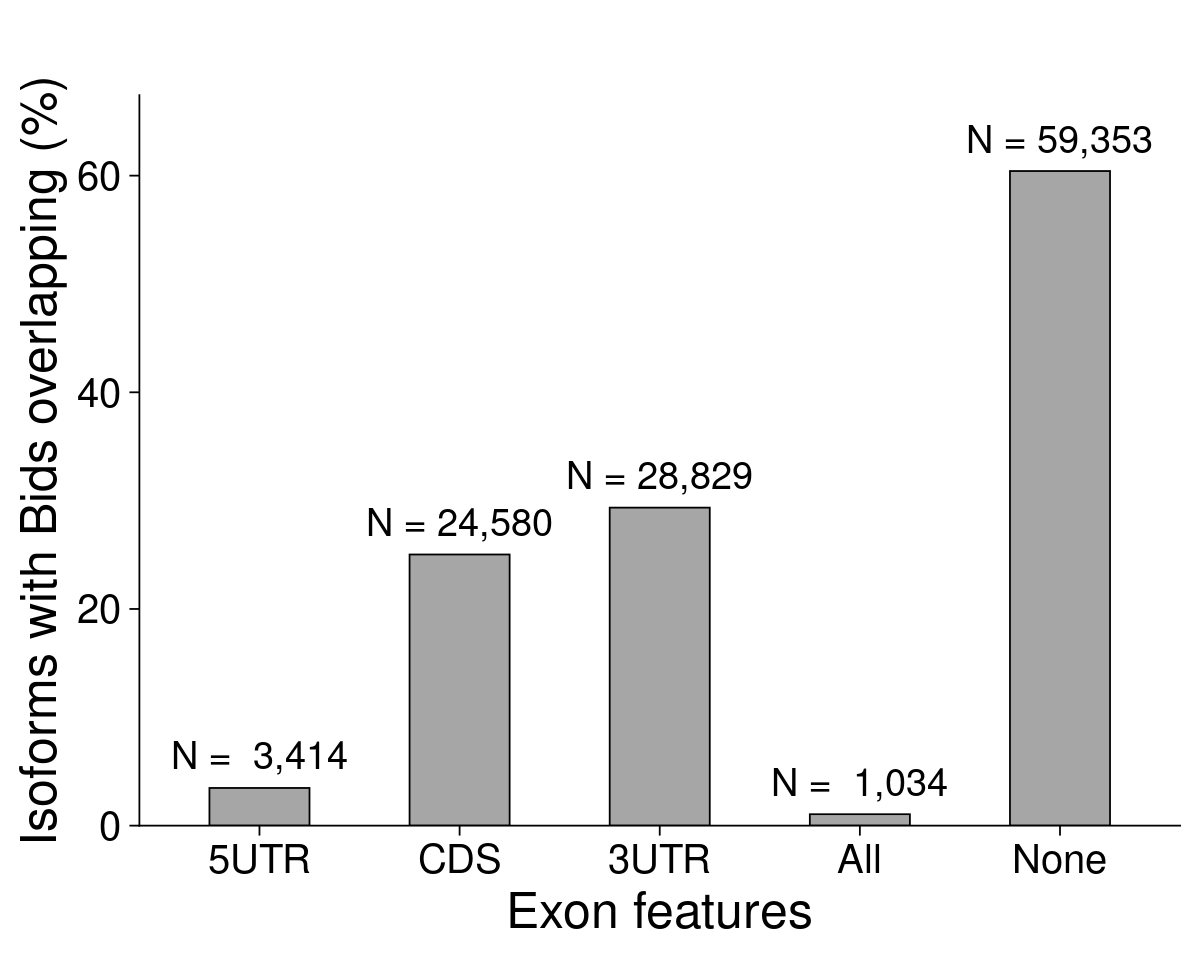

In [46]:

options(repr.plot.width=10, repr.plot.height=8)
data_use = ie_table[ie_table$Genome=="hg38" & ie_table$Gene_Metric=="Isoform",]
# Get the numbers to plot
rownames(data_use) <- data_use$Category
percs_plot = data_use[x_order,]$Per_Transcripts + 3
nums_plot = data_use[x_order,]$Number 

notss_isof_exon_bid_overlap_hg38_noheader <- ggplot2::ggplot(data_use,
       aes(x=factor(Category, 
                    levels=x_order), y=as.numeric(Per_Transcripts))) +
geom_bar(stat="identity", width=0.5, color='black',fill="gray65")+
  scale_y_continuous(expand = c(0, 0)) +
labs(title=" ",
     x="Exon features", 
     y = "Isoforms with Bids overlapping (%)") + #"% of bidirectionals overlapping")+
annotate("text", x=c(1,2,3,4, 5),
         y=percs_plot, 
         label= paste("N =", format(nums_plot, 
       scientific = FALSE, big.mark = ',')), size = 8) + 
theme_cowplot(24) +
coord_cartesian(ylim=c(0, max(percs_plot)+4)) +
theme(plot.title = element_text(hjust = 0.5),
      title = element_text(size = 30), 
      axis.title = element_text(size = 30), 
      axis.text = element_text(size = 24),
     axis.text.x = element_text(size = 24),
     legend.position="none") 

notss_isof_exon_bid_overlap_hg38_noheader

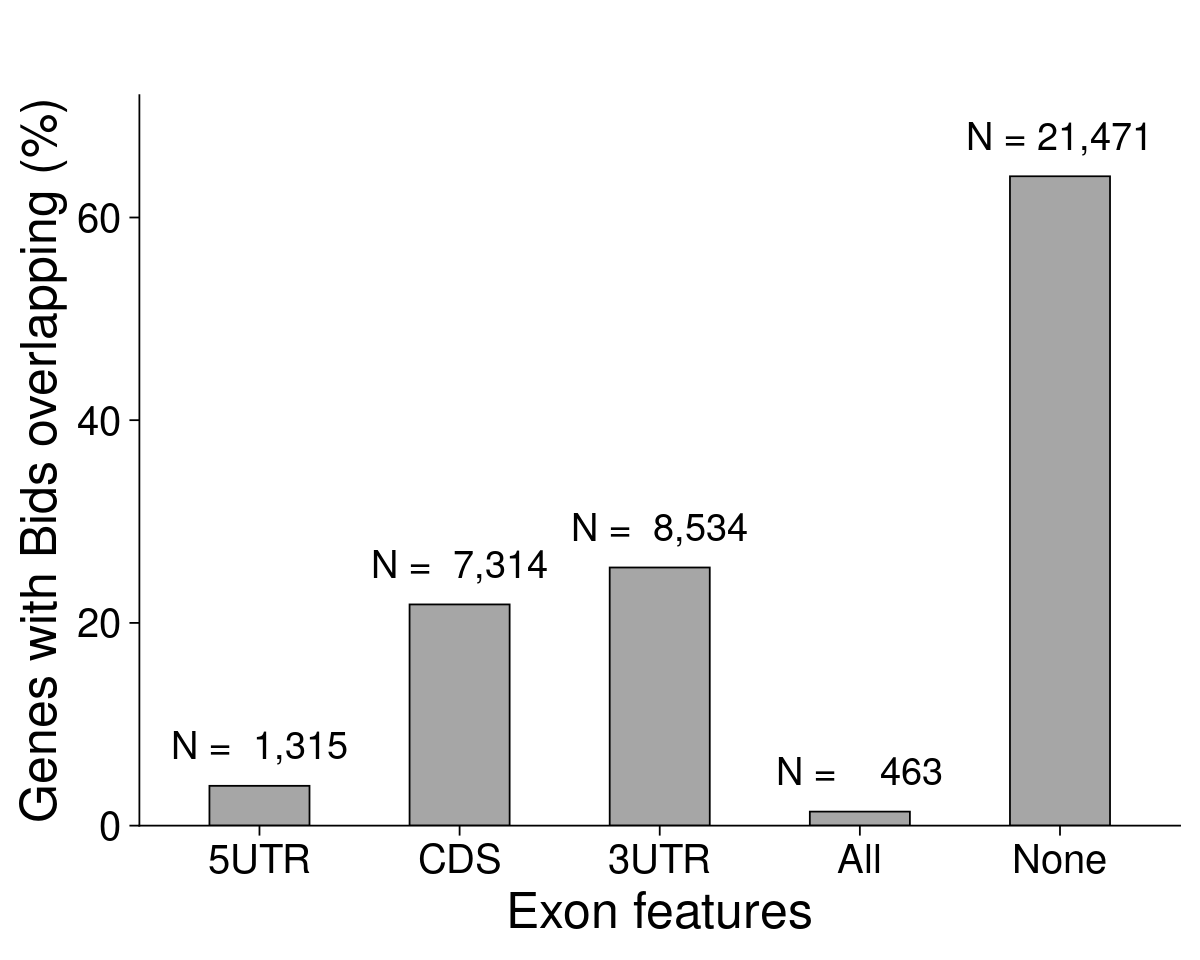

In [47]:

options(repr.plot.width=10, repr.plot.height=8)
data_use = ie_table[ie_table$Genome=="hg38" & ie_table$Gene_Metric=="Gene",]
# Get the numbers to plot
rownames(data_use) <- data_use$Category
percs_plot = data_use[x_order,]$Per_Transcripts + 4
nums_plot = data_use[x_order,]$Number 

notss_gene_exon_bid_overlap_hg38_noheader <- ggplot2::ggplot(data_use,
       aes(x=factor(Category, 
                    levels=x_order), y=as.numeric(Per_Transcripts))) +
geom_bar(stat="identity", width=0.5, color='black',fill="gray65")+
  scale_y_continuous(expand = c(0, 0)) +
labs(title=" ",
     x="Exon features", 
     y = "Genes with Bids overlapping (%)") + #"% of bidirectionals overlapping")+
annotate("text", x=c(1,2,3,4, 5),
         y=percs_plot, 
         label= paste("N =", format(nums_plot, 
       scientific = FALSE, big.mark = ',')), size = 8) + 
theme_cowplot(24) +
coord_cartesian(ylim=c(0, max(percs_plot)+4)) +
theme(plot.title = element_text(hjust = 0.5),
      title = element_text(size = 30), 
      axis.title = element_text(size = 30), 
      axis.text = element_text(size = 24),
     axis.text.x = element_text(size = 24),
     legend.position="none") 

notss_gene_exon_bid_overlap_hg38_noheader

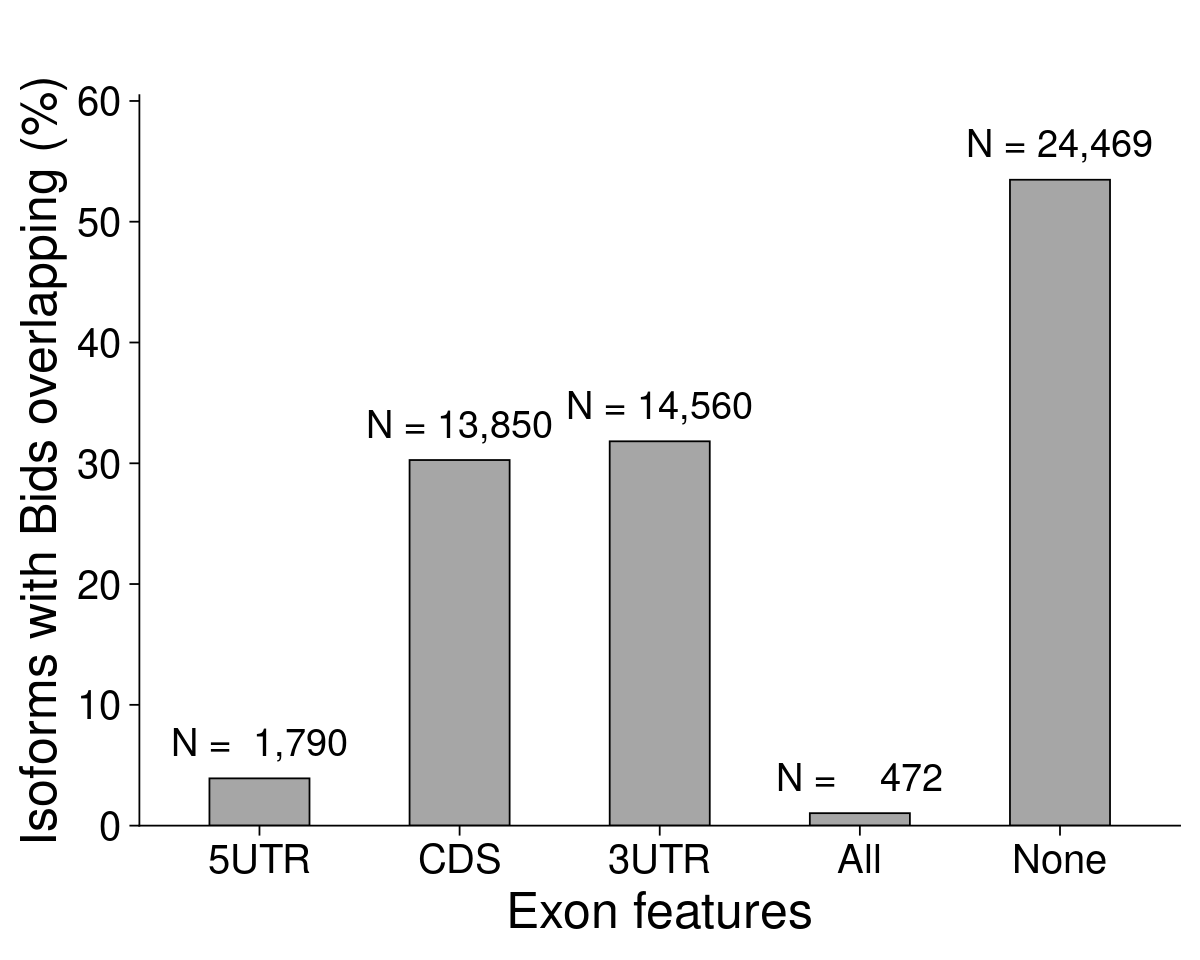

In [48]:

options(repr.plot.width=10, repr.plot.height=8)
data_use = ie_table[ie_table$Genome=="mm10" & ie_table$Gene_Metric=="Isoform",]
# Get the numbers to plot
rownames(data_use) <- data_use$Category
percs_plot = data_use[x_order,]$Per_Transcripts + 3
nums_plot = data_use[x_order,]$Number 

notss_isof_exon_bid_overlap_mm10_noheader <- ggplot2::ggplot(data_use,
       aes(x=factor(Category, 
                    levels=x_order), y=as.numeric(Per_Transcripts))) +
geom_bar(stat="identity", width=0.5, color='black',fill="gray65")+
  scale_y_continuous(expand = c(0, 0)) +
labs(title=" ",
     x="Exon features", 
     y = "Isoforms with Bids overlapping (%)") + #"% of bidirectionals overlapping")+
annotate("text", x=c(1,2,3,4, 5),
         y=percs_plot, 
         label= paste("N =", format(nums_plot, 
       scientific = FALSE, big.mark = ',')), size = 8) + 
theme_cowplot(24) +
coord_cartesian(ylim=c(0, max(percs_plot)+4)) +
theme(plot.title = element_text(hjust = 0.5),
      title = element_text(size = 30), 
      axis.title = element_text(size = 30), 
      axis.text = element_text(size = 24),
     axis.text.x = element_text(size = 24),
     legend.position="none") 

notss_isof_exon_bid_overlap_mm10_noheader

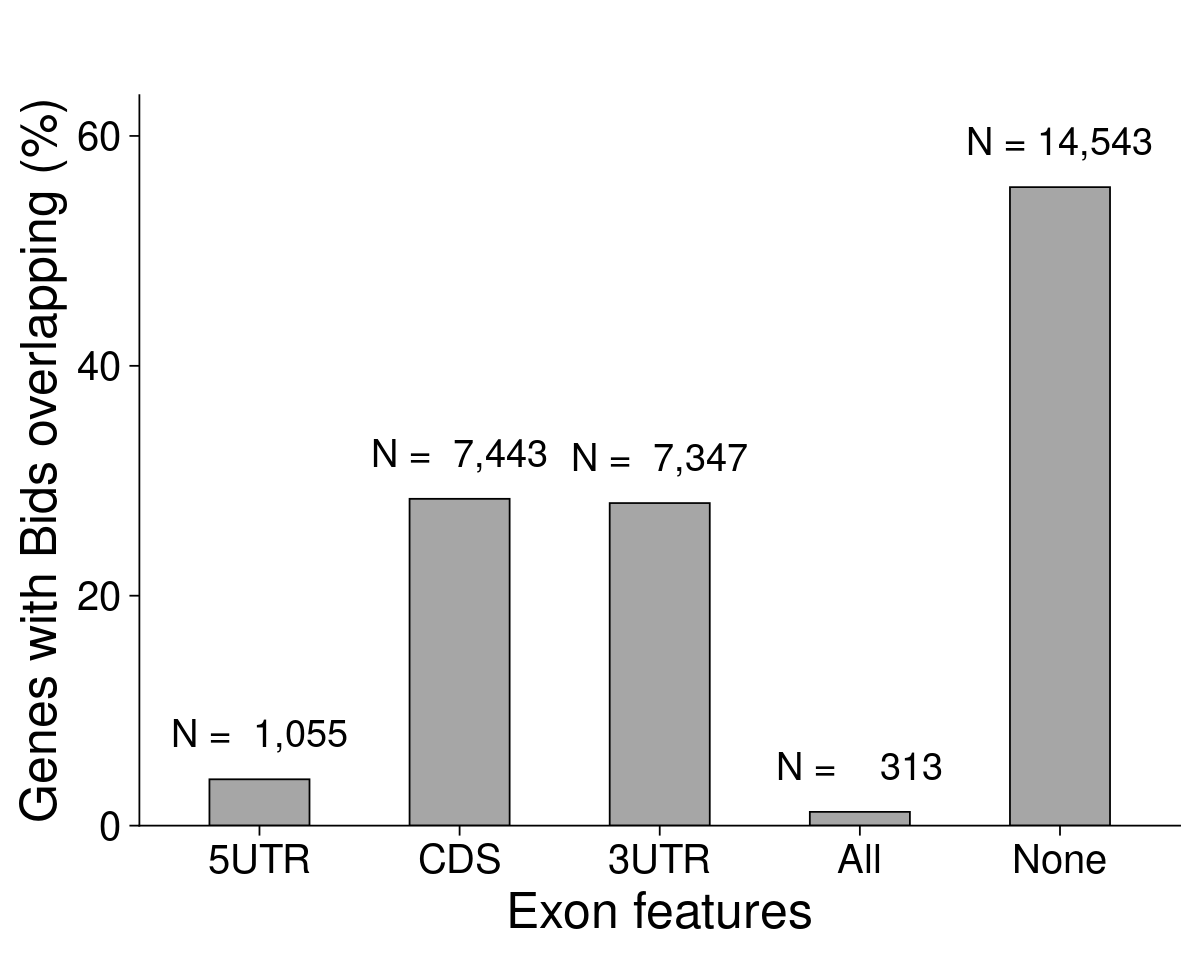

In [49]:

options(repr.plot.width=10, repr.plot.height=8)
data_use = ie_table[ie_table$Genome=="mm10" & ie_table$Gene_Metric=="Gene",]
# Get the numbers to plot
rownames(data_use) <- data_use$Category
percs_plot = data_use[x_order,]$Per_Transcripts + 4
nums_plot = data_use[x_order,]$Number 

notss_gene_exon_bid_overlap_mm10_noheader <- ggplot2::ggplot(data_use,
       aes(x=factor(Category, 
                    levels=x_order), y=as.numeric(Per_Transcripts))) +
geom_bar(stat="identity", width=0.5, color='black',fill="gray65")+
  scale_y_continuous(expand = c(0, 0)) +
labs(title=" ",
     x="Exon features", 
     y = "Genes with Bids overlapping (%)") + #"% of bidirectionals overlapping")+
annotate("text", x=c(1,2,3,4, 5),
         y=percs_plot, 
         label= paste("N =", format(nums_plot, 
       scientific = FALSE, big.mark = ',')), size = 8) + 
theme_cowplot(24) +
coord_cartesian(ylim=c(0, max(percs_plot)+4)) +
theme(plot.title = element_text(hjust = 0.5),
      title = element_text(size = 30), 
      axis.title = element_text(size = 30), 
      axis.text = element_text(size = 24),
     axis.text.x = element_text(size = 24),
     legend.position="none") 

notss_gene_exon_bid_overlap_mm10_noheader

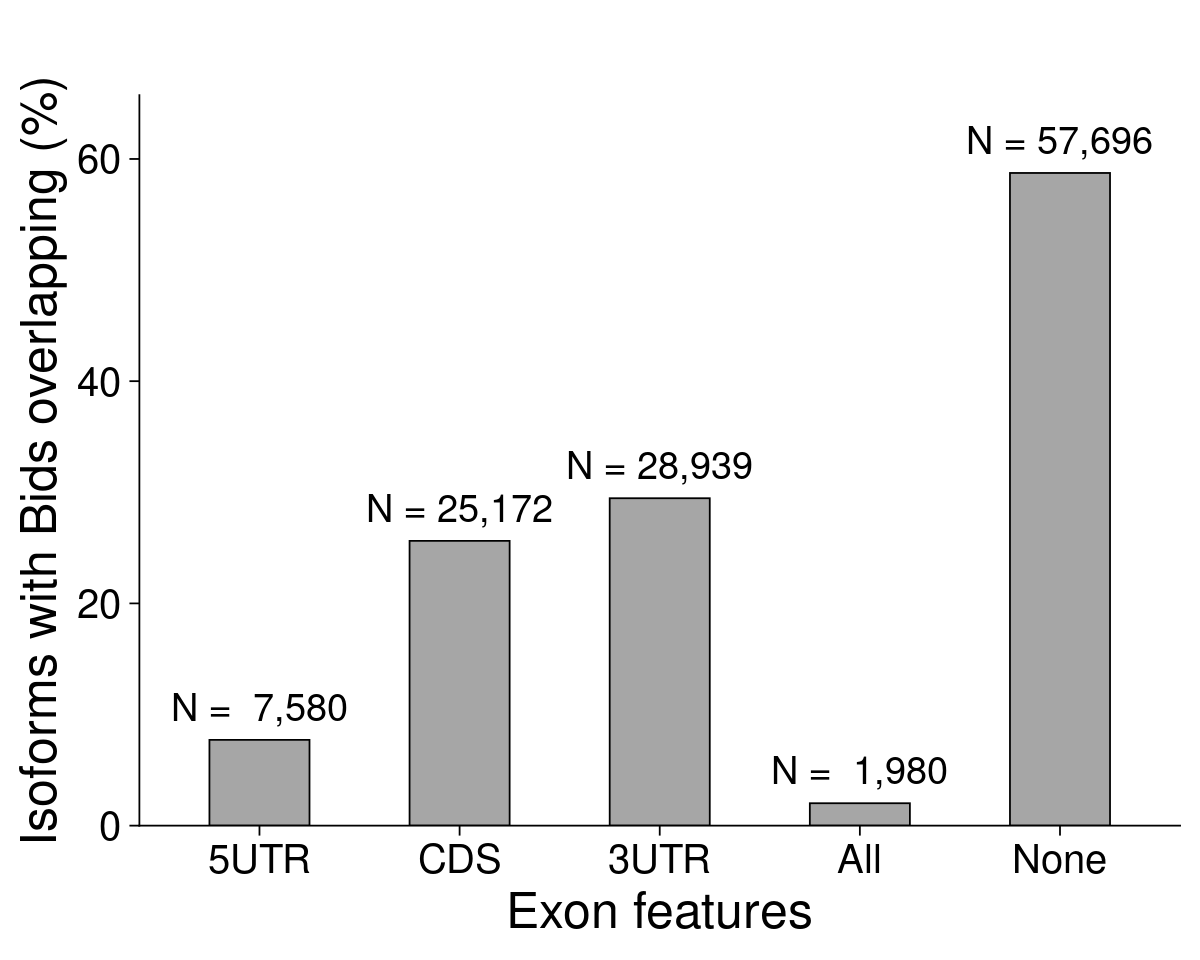

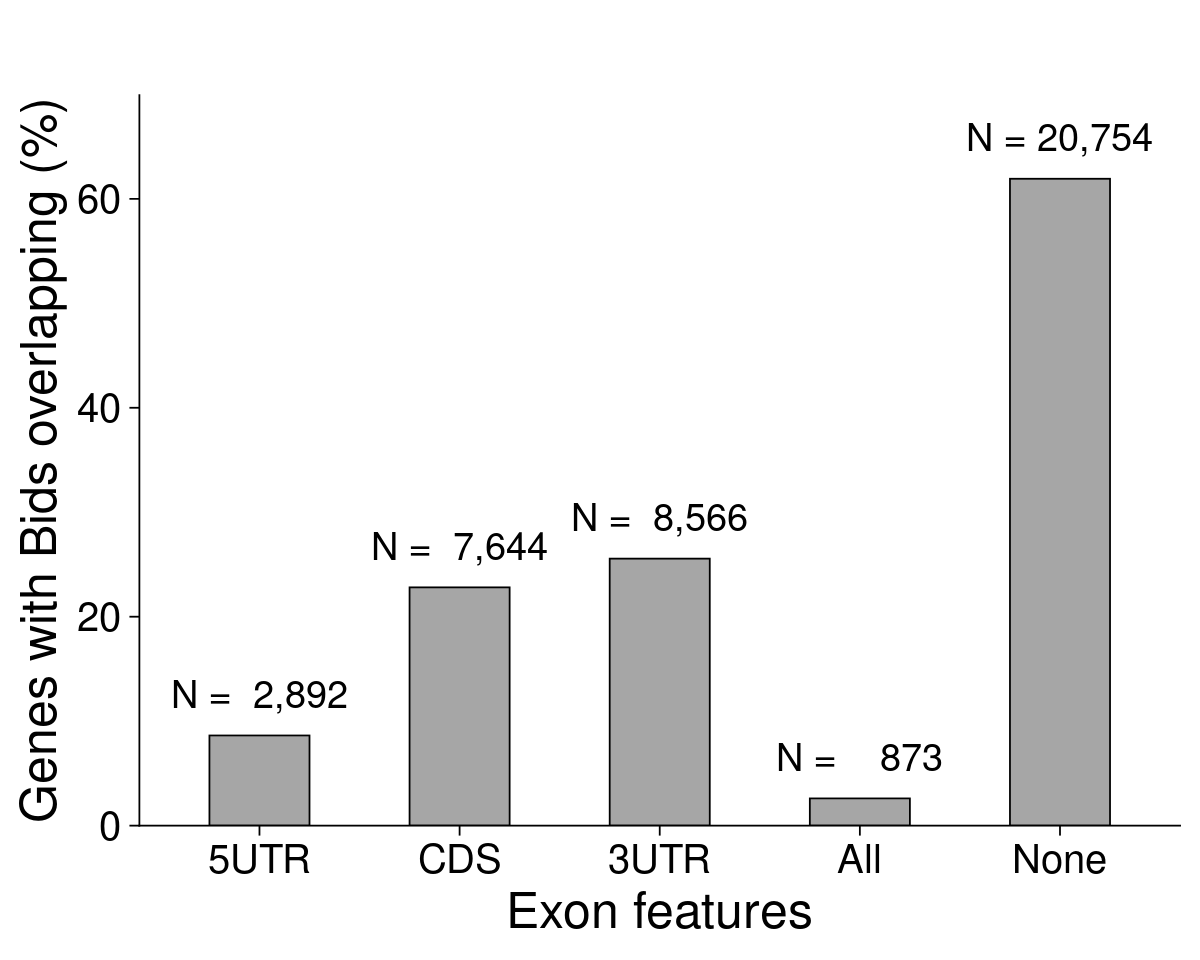

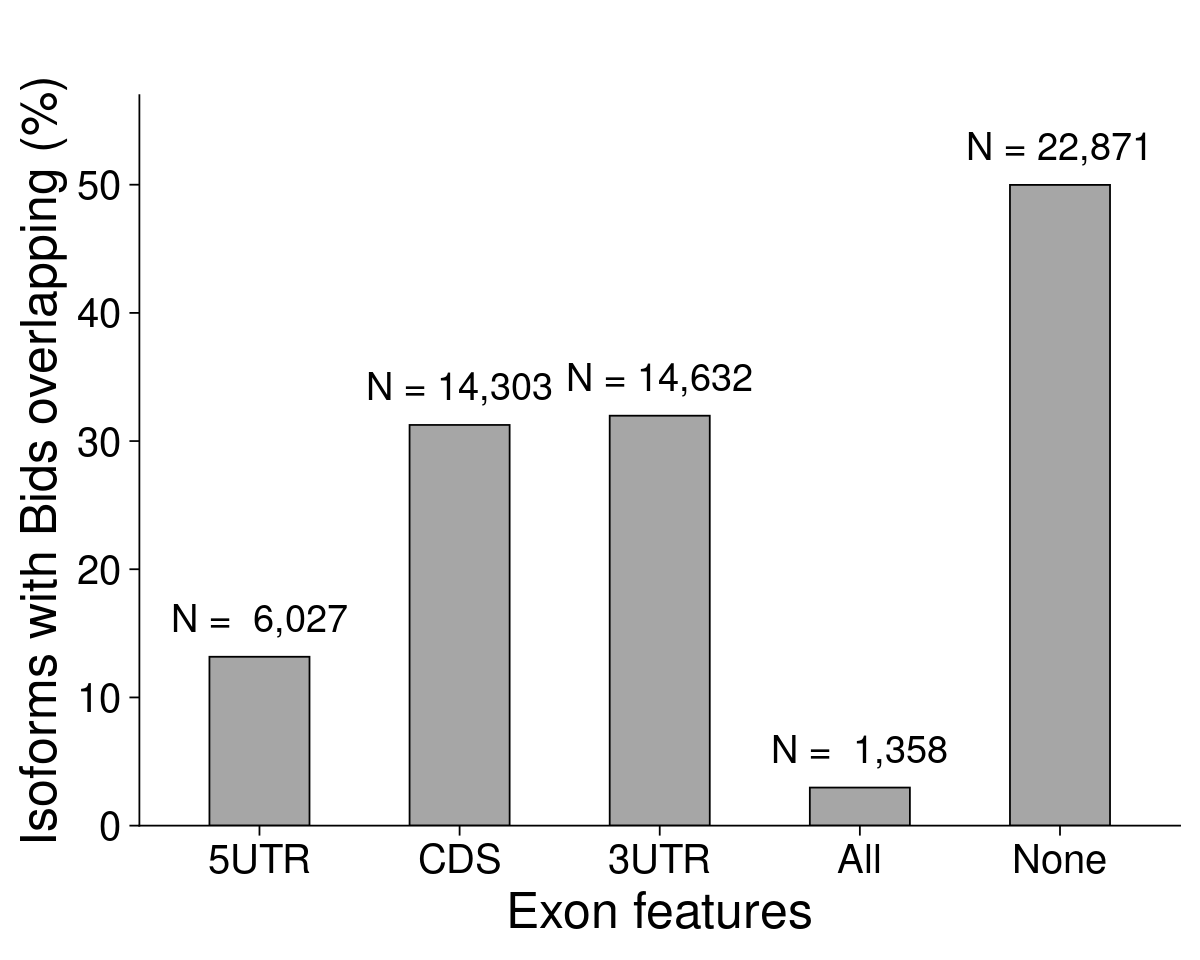

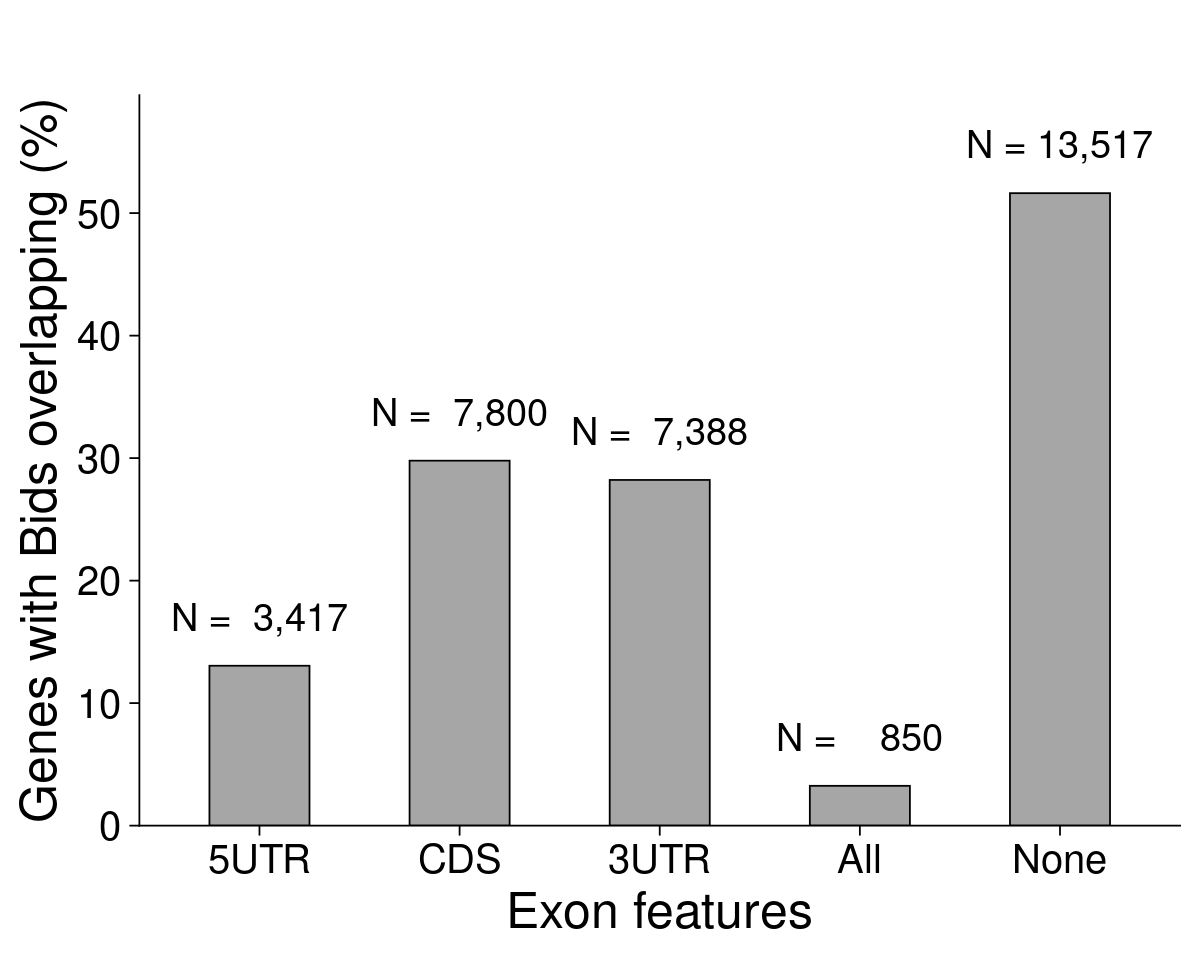

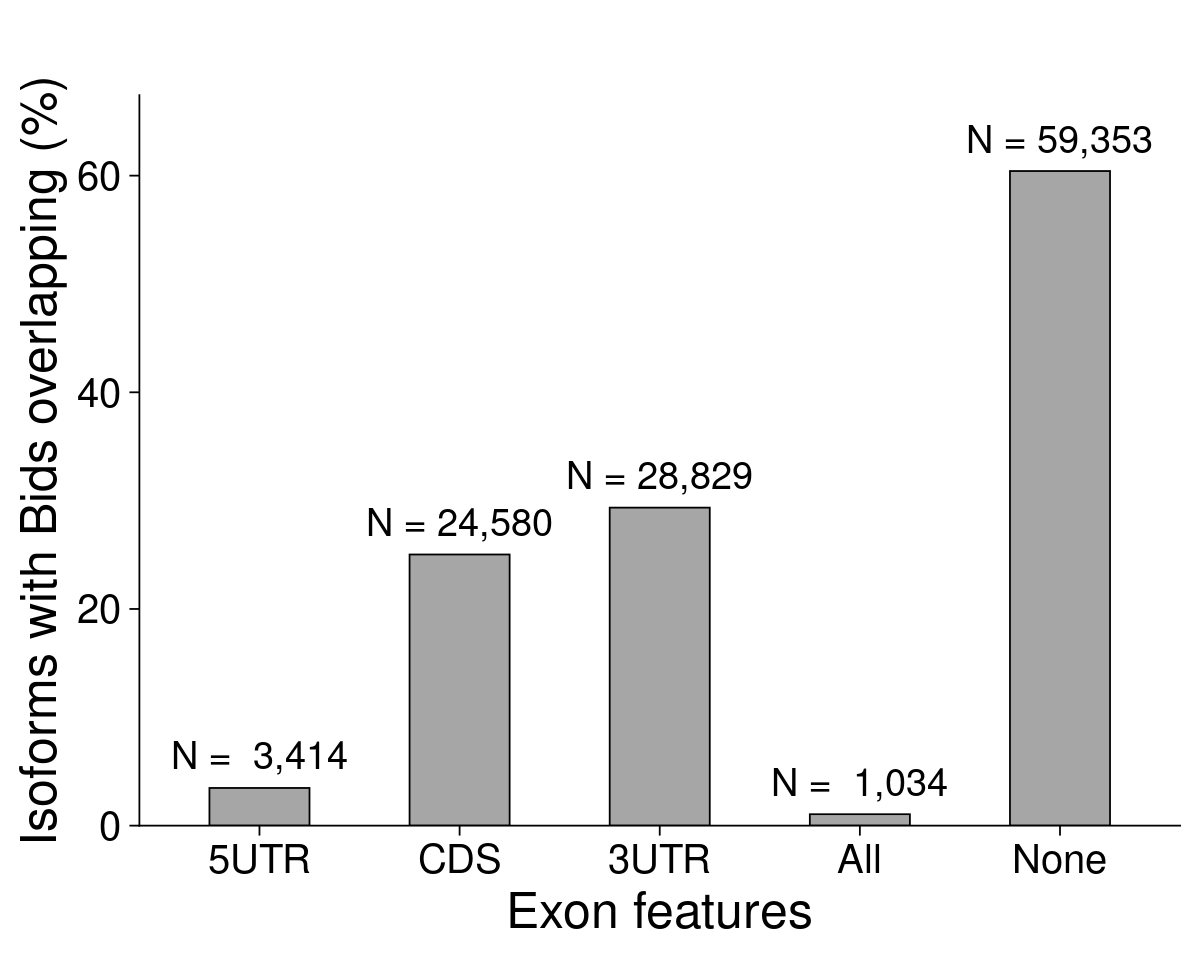

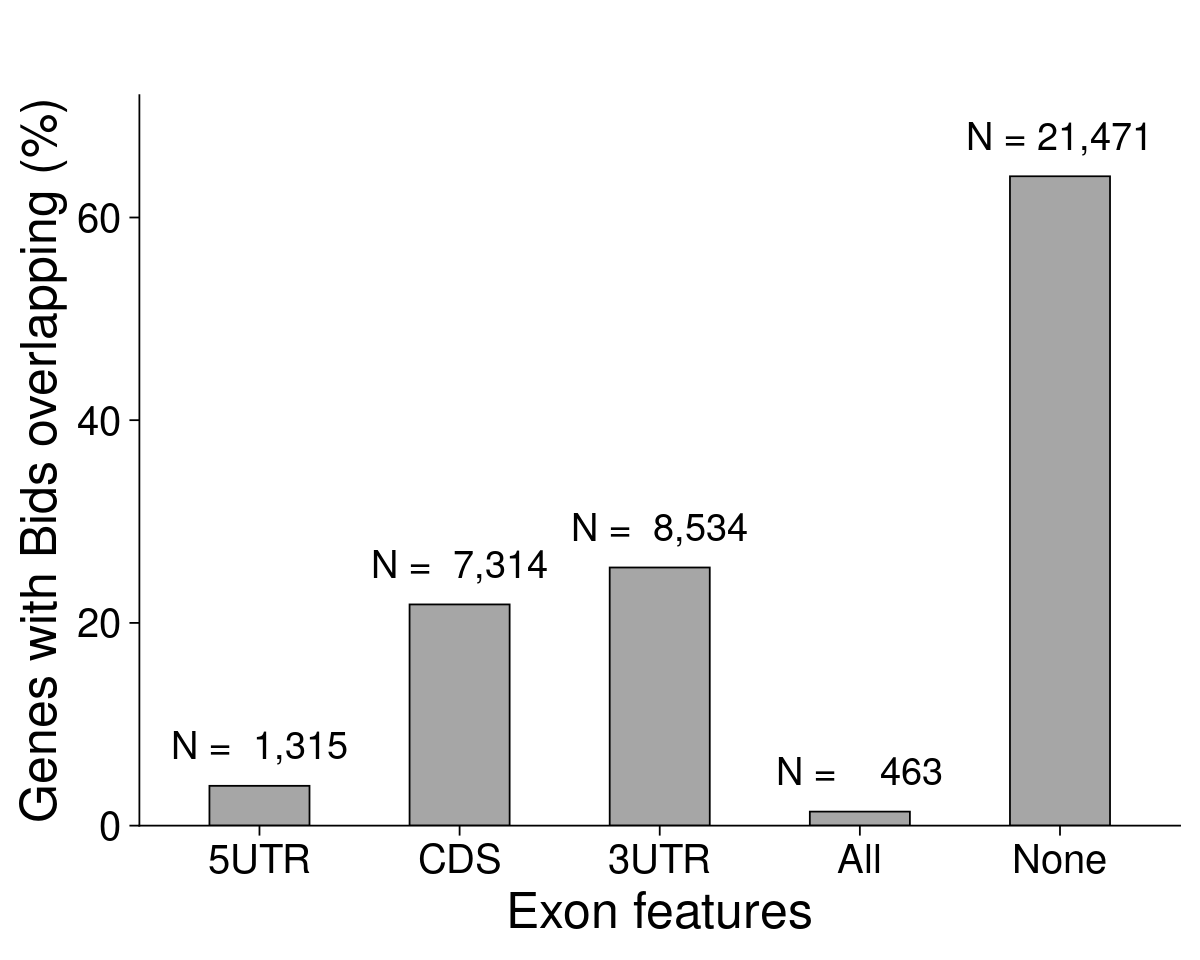

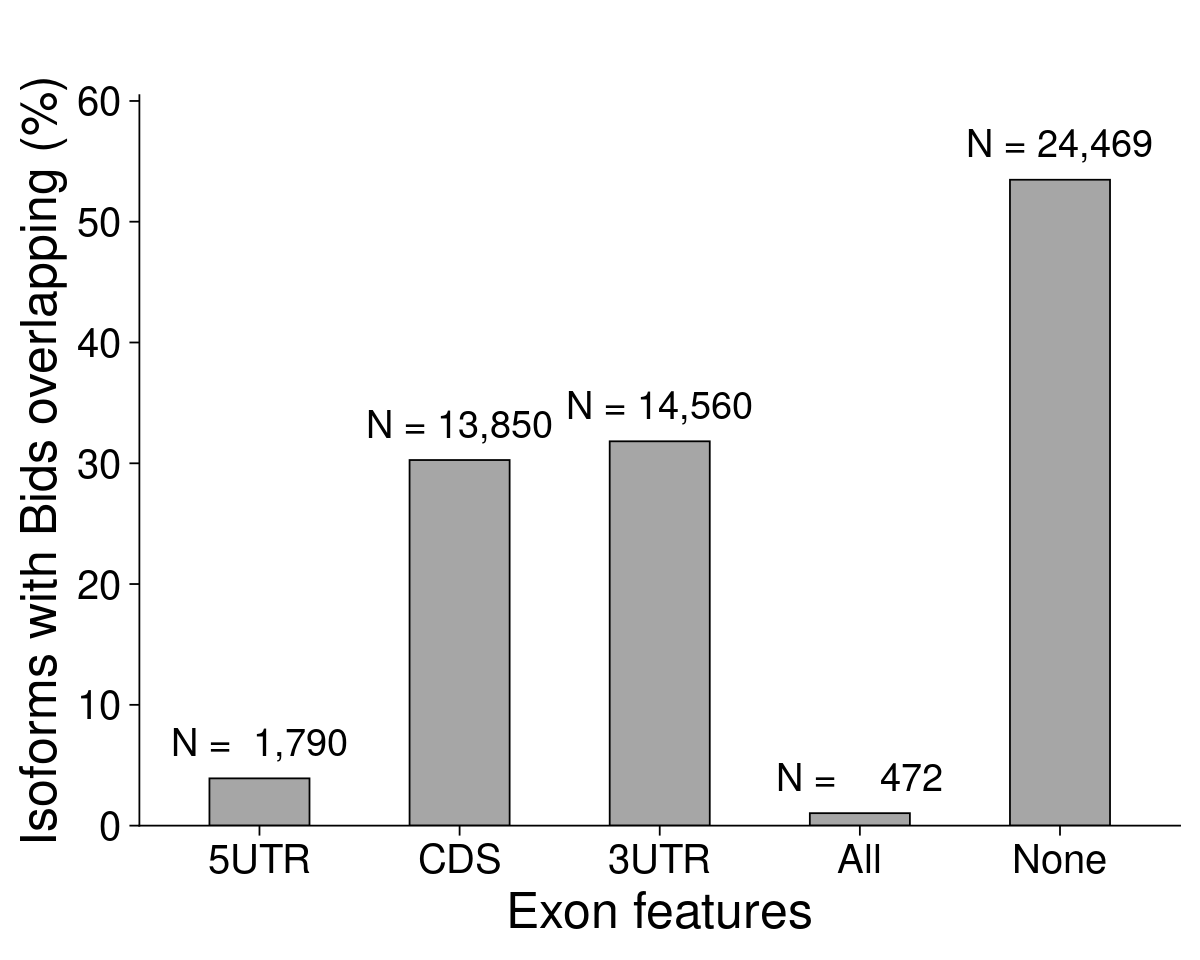

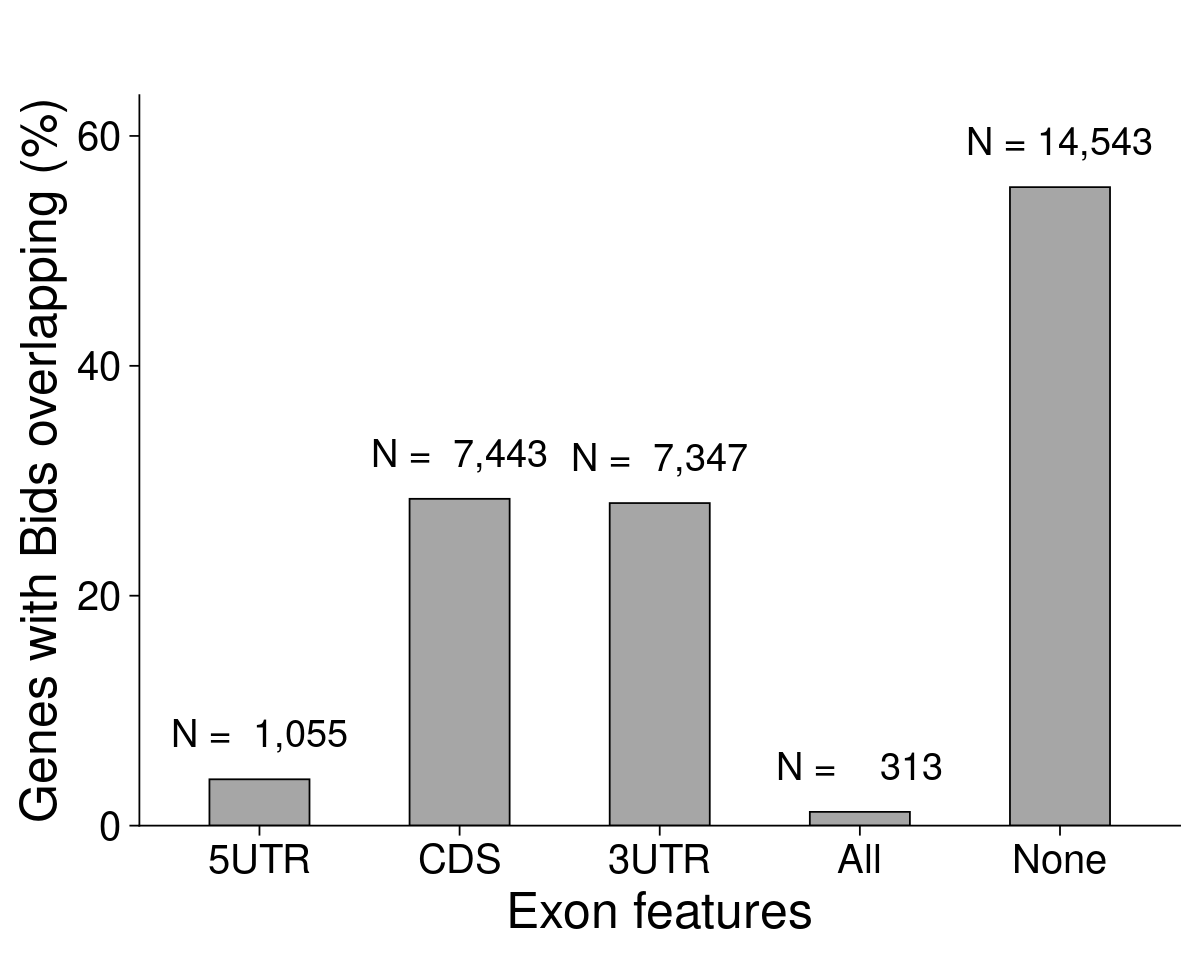

In [50]:
isof_exon_bid_overlap_hg38_noheader
gene_exon_bid_overlap_hg38_noheader
isof_exon_bid_overlap_mm10_noheader
gene_exon_bid_overlap_mm10_noheader

notss_isof_exon_bid_overlap_hg38_noheader
notss_gene_exon_bid_overlap_hg38_noheader
notss_isof_exon_bid_overlap_mm10_noheader
notss_gene_exon_bid_overlap_mm10_noheader

In [51]:
ggsave(notss_isof_exon_bid_overlap_hg38_noheader, width = 10, height = 8,
       filename = "/Users/hoto7260/projects/For_others/paper_figures/hg38_geneISOF_exon_refseq_overlap_bids_notss.pdf", 
       bg = "transparent")
ggsave(notss_gene_exon_bid_overlap_hg38_noheader, width = 10, height = 8,
       filename = "/Users/hoto7260/projects/For_others/paper_figures/hg38_gene_exon_refseq_overlap_bids_notss.pdf", 
       bg = "transparent")
ggsave(notss_isof_exon_bid_overlap_mm10_noheader, width = 10, height = 8,
       filename = "/Users/hoto7260/projects/For_others/paper_figures/mm10_geneISOF_exon_refseq_overlap_bids_notss.pdf", 
       bg = "transparent")
ggsave(notss_gene_exon_bid_overlap_mm10_noheader, width = 10, height = 8,
       filename = "/Users/hoto7260/projects/For_others/paper_figures/mm10_gene_exon_refseq_overlap_bids_notss.pdf", 
       bg = "transparent")

In [2]:
sessionInfo()

R version 4.4.0 (2024-04-24)
Platform: x86_64-pc-linux-gnu
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /usr/lib64/libopenblasp-r0.3.3.so;  LAPACK version 3.8.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: America/Denver
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] stringr_1.5.1     cowplot_1.1.3     ggplot2_3.5.1     data.table_1.15.4

loaded via a namespace (and not attached):
 [1] crayon_1.5.3        vctrs_0.6.5         cli_3.6.3          
 [4] rlang_1.1.4         stringi_1.8.4       generics_0.1.3     
 [7] jsonlite